# 🎙️ Arabic Dialect Detector — Classical ML Pipeline
> **Dataset:** ARCADE-Full (HuggingFace · `riotu-lab/ARCADE-full`)  
> **Task:** 4-class spoken-dialect classification (Algerian · Gulf · Levantine · Sudanese)  
> **Approach:** Handcrafted acoustic features → classical ML (SVM / RF / GBM / LogReg)


## 1 · Environment Setup & Imports


In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from collections import Counter

# Set plot style globally
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['font.size'] = 12
sns.set_palette("Set2")

print("All imports successful.")

All imports successful.


## 2 · Dataset Loading

Stream the full **ARCADE** dataset directly from HuggingFace.  

> ⏱ *This step can take a few minutes depending on network speed.*

**Dataset highlights:**
- Multi-country Arabic speech corpus
- Annotated with country, city, dialect type, emotion, and annotation confidence
- Includes both MSA (Modern Standard Arabic) and regional dialects

In [2]:
# Cell 2: Load ARCADE-full from HuggingFace
print("Loading ARCADE dataset... this may take a few minutes.")

ds = load_dataset("riotu-lab/ARCADE-full", split="train")

print(f"Total rows loaded: {len(ds)}")
print(f"Columns: {ds.column_names}")

Loading ARCADE dataset... this may take a few minutes.


README.md: 0.00B [00:00, ?B/s]

full_dataset/train-00000-of-00009.parque(…):   0%|          | 0.00/473M [00:00<?, ?B/s]

full_dataset/train-00001-of-00009.parque(…):   0%|          | 0.00/412M [00:00<?, ?B/s]

full_dataset/train-00002-of-00009.parque(…):   0%|          | 0.00/448M [00:00<?, ?B/s]

...

full_dataset/train-00006-of-00009.parque(…):   0%|          | 0.00/430M [00:00<?, ?B/s]

full_dataset/train-00007-of-00009.parque(…):   0%|          | 0.00/451M [00:00<?, ?B/s]

full_dataset/train-00008-of-00009.parque(…):   0%|          | 0.00/395M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6907 [00:00<?, ? examples/s]

Total rows loaded: 6907
Columns: ['audio', 'filename', 'duration', 'country', 'city', 'msa_or_dialect', 'emotion', 'keep_or_skip', 'confidence', 'audio_type', 'annotators', 'timestamp']


# 3 · Metadata Exploration

In [3]:
# Cell 3: Convert to DataFrame 

# exclude the 'audio' column to keep memory light during EDA
meta_cols = ['filename', 'duration', 'country', 'city',
             'msa_or_dialect', 'emotion', 'keep_or_skip',
             'confidence', 'audio_type', 'annotators']

df = ds.to_pandas()[meta_cols]

print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== COLUMN UNIQUE VALUES ===")
for col in meta_cols:
    if col not in ['filename', 'city']:
        print(f"\n{col}: {df[col].unique()}")

=== DATASET SHAPE ===
Rows: 6907, Columns: 10

=== MISSING VALUES ===
filename          0
duration          0
country           0
city              0
msa_or_dialect    0
emotion           0
keep_or_skip      0
confidence        0
audio_type        0
annotators        0
dtype: int64

=== COLUMN UNIQUE VALUES ===

duration: ['29.99' '30.0' '29.98' '29.93' '9.65' '28.21' '180.0' '22.0' '16.72'
 '29.62' '18.42' '21.77' '25.15' '12.77' '17.14' '25.96' '16.0']

country: ['Algeria' 'Yemen' 'United_Arab_Emirate' 'Jordan' 'Somalia' 'Bahrain'
 'Iraq' 'Lebanon' 'Morocco' 'Egypt' 'Saudi_Arabia' 'Kuwait' 'Oman'
 'Palestine' 'Sudan' 'Syria' 'Libya' 'Tunisia' 'Qatar']

msa_or_dialect: ['MSA' 'Dialect' 'Mixed' 'Not applicable' 'nan']

emotion: ['Neutral' 'Frustration' 'Excitement' 'Happiness' 'Sadness' 'Fear' 'Anger'
 'Surprise' 'nan']

keep_or_skip: ['Keep' 'Skip' 'nan']

confidence: ['sure' 'unsure' 'no idea' 'nan']

audio_type: ['Multiple speakers' 'Regular single speaker' 'No speech / Music'
 'Qur

## 4 · Data Filtering & Quality Control

In [4]:
# Cell 4: Filter out music, no-speech, and low-quality rows
print(f"Before filtering: {len(df)} rows")

# Step 1: Keep only rows marked 'Keep'
df = df[df['keep_or_skip'] == 'Keep'].copy()
print(f"After keep_or_skip filter: {len(df)} rows")

# Step 2: Keep only Dialect rows (remove MSA and Mixed - they blur dialect identity)
df = df[df['msa_or_dialect'] == 'Dialect'].copy()
print(f"After msa_or_dialect filter (Dialect only): {len(df)} rows")

# Step 3: Keep only real speech (remove music, ads, etc.)
valid_audio_types = ['Regular single speaker', 'Multiple speakers']
df = df[df['audio_type'].isin(valid_audio_types)].copy()
print(f"After audio_type filter: {len(df)} rows")

# Step 4: Keep only 'sure' confidence annotations
df = df[df['confidence'] == 'sure'].copy()
print(f"After confidence filter: {len(df)} rows")

df.reset_index(drop=True, inplace=True)
print(f"\nFinal clean dataset: {len(df)} rows")

Before filtering: 6907 rows
After keep_or_skip filter: 4539 rows
After msa_or_dialect filter (Dialect only): 2388 rows
After audio_type filter: 2383 rows
After confidence filter: 2263 rows

Final clean dataset: 2263 rows


## 5 · Dialect Group Mapping

In [5]:
# Cell 5: Map countries to the 5 target dialect groups
DIALECT_MAP = {
    # Algerian
    'Algeria': 'Algerian',

    # Sudanese
    'Sudan': 'Sudanese',

    # Levantine
    'Syria': 'Levantine',
    'Lebanon': 'Levantine',
    'Jordan': 'Levantine',
    'Palestine': 'Levantine',

    # Gulf
    'Saudi Arabia': 'Gulf',
    'UAE': 'Gulf',
    'Kuwait': 'Gulf',
    'Qatar': 'Gulf',
    'Oman': 'Gulf',
    'Bahrain': 'Gulf',


}

# Apply mapping (rows with countries not in map will be NaN and dropped)
df['dialect_group'] = df['country'].map(DIALECT_MAP)

# Check what countries exist in data that are NOT in our 5 groups
unmapped = df[df['dialect_group'].isna()]['country'].value_counts()
print("Countries NOT in our 4 dialect groups (will be dropped):")
print(unmapped)

# Drop unmapped rows
df = df[df['dialect_group'].notna()].copy()
df.reset_index(drop=True, inplace=True)

print(f"\nFinal dataset after dialect mapping: {len(df)} rows")
print(f"\nDialect class distribution:")
print(df['dialect_group'].value_counts())

Countries NOT in our 4 dialect groups (will be dropped):
country
Egypt                  245
Morocco                198
United_Arab_Emirate    195
Saudi_Arabia           144
Yemen                   68
Iraq                    66
Somalia                 59
Libya                   43
Tunisia                  5
Name: count, dtype: int64

Final dataset after dialect mapping: 1240 rows

Dialect class distribution:
dialect_group
Algerian     451
Levantine    287
Gulf         268
Sudanese     234
Name: count, dtype: int64


## 6 · Exploratory Data Analysis

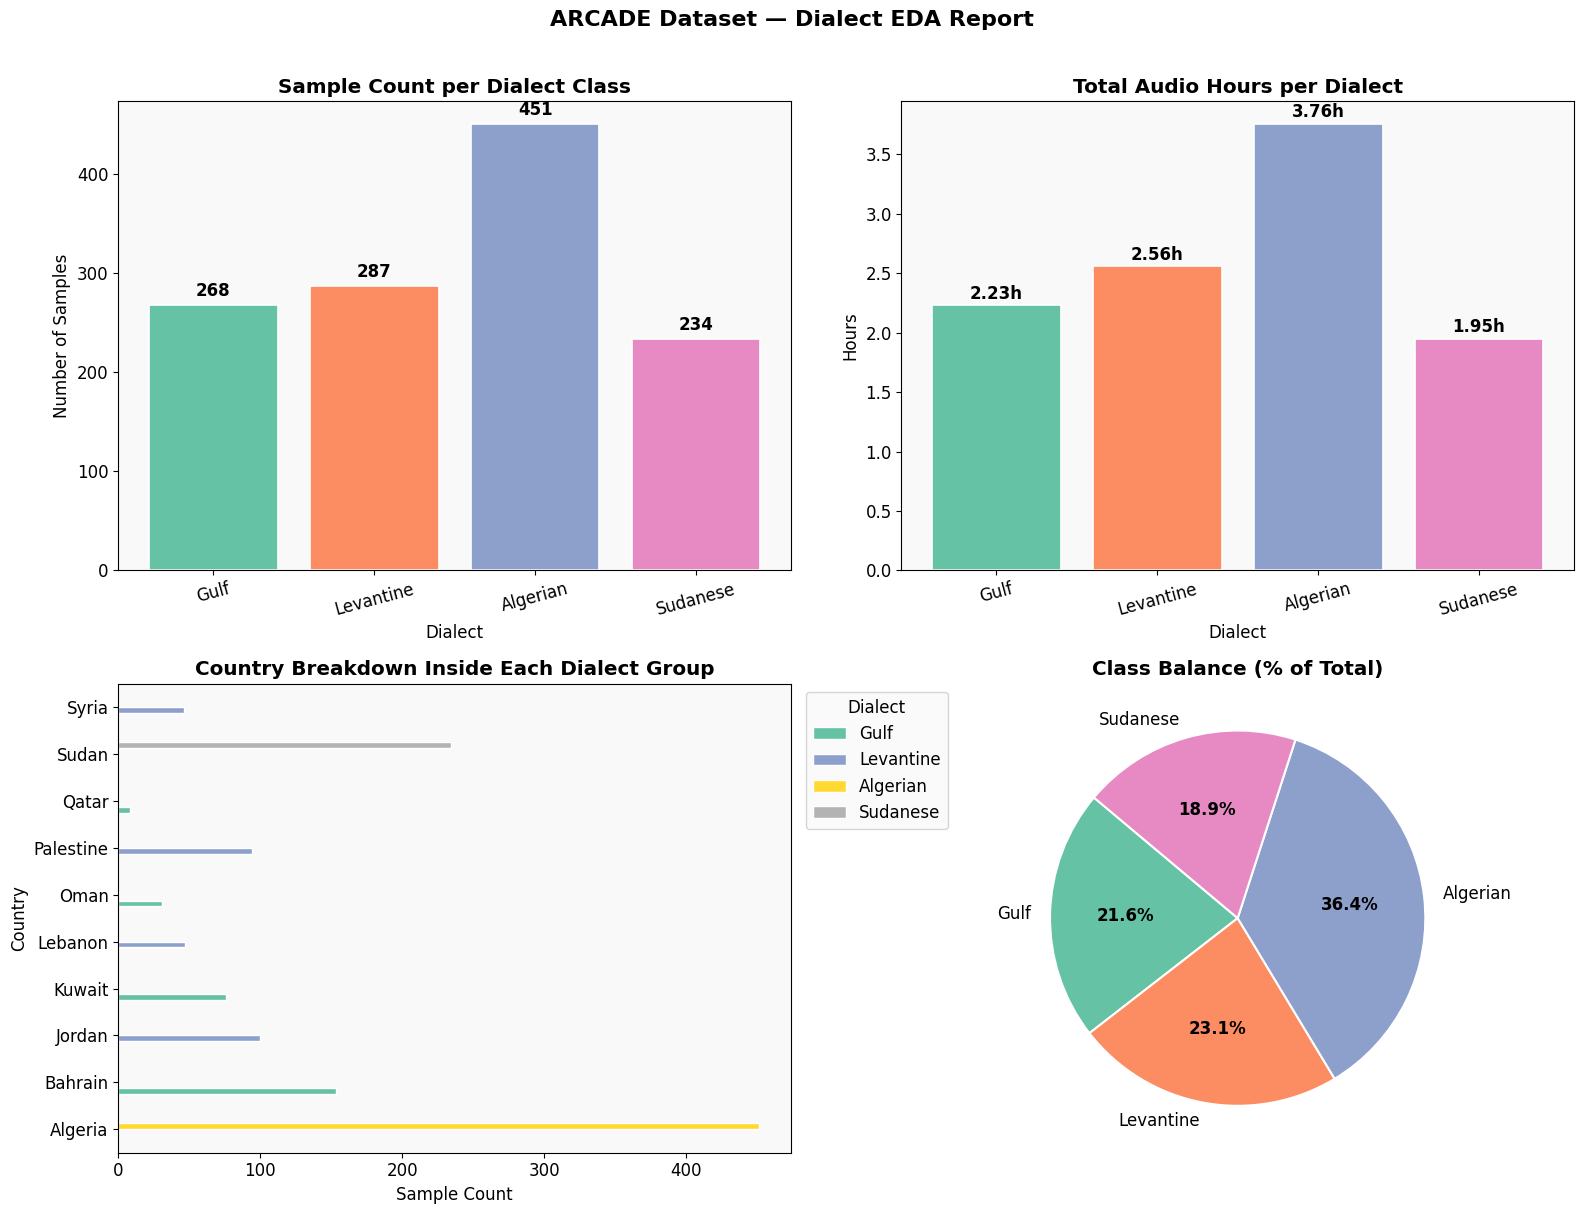

EDA plot saved as arcade_eda.png


In [6]:
# Cell 6: Comprehensive EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ARCADE Dataset — Dialect EDA Report', fontsize=16, fontweight='bold', y=1.01)

dialect_order = ['Gulf', 'Levantine', 'Algerian', 'Sudanese']
palette = sns.color_palette("Set2", 5)
color_map = dict(zip(dialect_order, palette))

# --- Plot 1: Sample count per dialect ---
ax1 = axes[0, 0]
counts = df['dialect_group'].value_counts().reindex(dialect_order).fillna(0)
bars = ax1.bar(counts.index, counts.values,
               color=[color_map[d] for d in counts.index], edgecolor='white', linewidth=1.2)
ax1.set_title('Sample Count per Dialect Class', fontweight='bold')
ax1.set_xlabel('Dialect')
ax1.set_ylabel('Number of Samples')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(val)), ha='center', va='bottom', fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

# --- Plot 2: Total audio hours per dialect ---
ax2 = axes[0, 1]
# duration is stored as string in ARCADE, convert
df['duration_sec'] = pd.to_numeric(df['duration'], errors='coerce').fillna(30.0)
hours = df.groupby('dialect_group')['duration_sec'].sum() / 3600
hours = hours.reindex(dialect_order).fillna(0)
bars2 = ax2.bar(hours.index, hours.values,
                color=[color_map[d] for d in hours.index], edgecolor='white', linewidth=1.2)
ax2.set_title('Total Audio Hours per Dialect', fontweight='bold')
ax2.set_xlabel('Dialect')
ax2.set_ylabel('Hours')
for bar, val in zip(bars2, hours.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}h', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# --- Plot 3: Country breakdown inside each dialect ---
ax3 = axes[1, 0]
country_dialect = df.groupby(['dialect_group', 'country']).size().reset_index(name='count')
pivot = country_dialect.pivot(index='country', columns='dialect_group', values='count').fillna(0)
pivot = pivot[[c for c in dialect_order if c in pivot.columns]]
pivot.plot(kind='barh', ax=ax3, colormap='Set2', edgecolor='white')
ax3.set_title('Country Breakdown Inside Each Dialect Group', fontweight='bold')
ax3.set_xlabel('Sample Count')
ax3.set_ylabel('Country')
ax3.legend(title='Dialect', bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Plot 4: Class balance pie chart ---
ax4 = axes[1, 1]
pie_counts = df['dialect_group'].value_counts().reindex(dialect_order).fillna(0)
wedges, texts, autotexts = ax4.pie(
    pie_counts.values,
    labels=pie_counts.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontweight('bold')
ax4.set_title('Class Balance (% of Total)', fontweight='bold')

plt.tight_layout()
plt.savefig('arcade_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved as arcade_eda.png")

## 7 · Dataset Summary Report


In [7]:
# Cell 7: Clean summary report before moving to feature extraction
print("=" * 55)
print("       ARCADE DATASET — FINAL SUMMARY REPORT")
print("=" * 55)

total_samples = len(df)
total_hours = df['duration_sec'].sum() / 3600

print(f"\nTotal usable samples : {total_samples}")
print(f"Total audio duration : {total_hours:.2f} hours")
print(f"Avg clip duration    : {df['duration_sec'].mean():.1f} seconds")
print(f"Dialect classes      : {df['dialect_group'].nunique()}")
print(f"Countries covered    : {df['country'].nunique()}")
print(f"Cities covered       : {df['city'].nunique()}")

print("\n--- Per-Dialect Breakdown ---")
summary = df.groupby('dialect_group').agg(
    samples=('filename', 'count'),
    hours=('duration_sec', lambda x: round(x.sum() / 3600, 2)),
    countries=('country', 'nunique'),
    cities=('city', 'nunique')
).reindex(dialect_order)

print(summary.to_string())

print("\n--- Class Imbalance Check ---")
max_class = df['dialect_group'].value_counts().max()
min_class = df['dialect_group'].value_counts().min()
ratio = max_class / min_class
print(f"Max / Min class ratio: {ratio:.2f}x")
if ratio > 3:
    print("WARNING: Significant imbalance detected. We will handle this in training.")
else:
    print("Class balance is acceptable.")

print("\n[Next Step] --> Feature Extraction (MFCC + Spectral + Prosodic)")

       ARCADE DATASET — FINAL SUMMARY REPORT

Total usable samples : 1240
Total audio duration : 10.50 hours
Avg clip duration    : 30.5 seconds
Dialect classes      : 4
Countries covered    : 10
Cities covered       : 30

--- Per-Dialect Breakdown ---
               samples  hours  countries  cities
dialect_group                                   
Gulf               268   2.23          4       5
Levantine          287   2.56          4      11
Algerian           451   3.76          1       9
Sudanese           234   1.95          1       5

--- Class Imbalance Check ---
Max / Min class ratio: 1.93x
Class balance is acceptable.

[Next Step] --> Feature Extraction (MFCC + Spectral + Prosodic)


---

## 8 · Audio Preprocessing Functions

Define the full **audio preprocessing pipeline**:

| Function | Purpose |
|----------|---------|
| `load_and_resample()` | Resample all audio to 16 kHz mono |
| `normalize_loudness()` | Peak normalise to 0.95 amplitude |
| `apply_vad()` | Voice Activity Detection — strip silence and noise |
| `pad_or_trim()` | Standardise all clips to exactly 30 seconds |
| `preprocess_clip()` | Orchestrate the above; drop clips with < 3 s of speech |

**Constants:**

```
TARGET_SR       = 16 000 Hz
TARGET_DURATION = 30 s
MIN_SPEECH_SEC  = 3 s
```


In [8]:
# CELL 8:Audio Preprocessing Functions                             

 
import librosa
import numpy as np
import soundfile as sf
import os
 
TARGET_SR       = 16000
TARGET_DURATION = 30.0
MIN_SPEECH_SEC  = 3.0
 
 
def load_and_resample(audio_dict: dict, target_sr: int = TARGET_SR):
    waveform = np.array(audio_dict['array'], dtype=np.float32)
    sr       = audio_dict['sampling_rate']
    if waveform.ndim == 2:
        waveform = waveform.mean(axis=0)
    if sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
    return waveform, target_sr
 
 
def normalize_loudness(waveform: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(waveform))
    if peak < 1e-6:
        return waveform
    return waveform * (0.95 / peak)
 
 
def apply_vad(waveform, sr, top_db=30, frame_length=2048, hop_length=512):
    trimmed, _ = librosa.effects.trim(waveform, top_db=top_db,
                                       frame_length=frame_length,
                                       hop_length=hop_length)
    intervals = librosa.effects.split(trimmed, top_db=top_db,
                                       frame_length=frame_length,
                                       hop_length=hop_length)
    if len(intervals) == 0:
        return trimmed
    speech_chunks = [trimmed[start:end] for start, end in intervals]
    return np.concatenate(speech_chunks)
 
 
def pad_or_trim(waveform, sr, target_duration=TARGET_DURATION):
    target_len  = int(target_duration * sr)
    current_len = len(waveform)
    if current_len > target_len:
        start = (current_len - target_len) // 2
        return waveform[start: start + target_len]
    elif current_len < target_len:
        pad_total = target_len - current_len
        pad_left  = pad_total // 2
        pad_right = pad_total - pad_left
        return np.pad(waveform, (pad_left, pad_right), mode='constant')
    return waveform
 
 
def preprocess_clip(audio_dict: dict):
    try:
        waveform, sr = load_and_resample(audio_dict)
        waveform     = normalize_loudness(waveform)
        speech       = apply_vad(waveform, sr)
        if len(speech) / sr < MIN_SPEECH_SEC:
            return None
        return pad_or_trim(speech, sr)
    except Exception:
        return None
 
 
print("Preprocessing functions defined.")
print(f"  Target sample rate : {TARGET_SR} Hz")
print(f"  Target duration    : {TARGET_DURATION} seconds")
print(f"  Min speech required: {MIN_SPEECH_SEC} seconds")

Preprocessing functions defined.
  Target sample rate : 16000 Hz
  Target duration    : 30.0 seconds
  Min speech required: 3.0 seconds


## 9 · Batch Preprocessing


In [9]:
# Cell 9: Apply preprocessing to all samples and build processed dataset


from tqdm.notebook import tqdm

# We need the audio column now — reload ds subset filtered by our df indices
# We'll use the filename to match back to the original dataset

# Build a filename -> dialect_group lookup from our filtered df
filename_to_dialect = dict(zip(df['filename'], df['dialect_group']))

print(f"Processing {len(ds)} raw rows (will filter down to our {len(df)} clean rows)...")

processed_records = []
skipped_no_speech = 0
skipped_not_in_filter = 0

for i, sample in enumerate(tqdm(ds, desc="Preprocessing audio")):
    filename = sample['filename']

    # Skip rows that didn't pass our metadata filter
    if filename not in filename_to_dialect:
        skipped_not_in_filter += 1
        continue

    dialect = filename_to_dialect[filename]

    # Run full preprocessing pipeline
    waveform = preprocess_clip(sample['audio'])

    if waveform is None:
        skipped_no_speech += 1
        continue

    processed_records.append({
        'filename'     : filename,
        'waveform'     : waveform,
        'dialect_group': dialect,
        'country'      : sample['country'],
        'city'         : sample['city'],
    })

print("\n=== Preprocessing Summary ===")
print(f"Total raw rows           : {len(ds)}")
print(f"Skipped (not in filter)  : {skipped_not_in_filter}")
print(f"Skipped (< {MIN_SPEECH_SEC}s speech)  : {skipped_no_speech}")
print(f"Successfully processed   : {len(processed_records)}")

# Count per dialect after preprocessing
from collections import Counter
dialect_counts_post = Counter([r['dialect_group'] for r in processed_records])
print("\nDialect distribution after preprocessing:")
for dialect in ['Egyptian', 'Gulf', 'Levantine', 'Algerian', 'Sudanese']:
    print(f"  {dialect:<12}: {dialect_counts_post.get(dialect, 0)} samples")

Processing 6907 raw rows (will filter down to our 1240 clean rows)...


Preprocessing audio:   0%|          | 0/6907 [00:00<?, ?it/s]


=== Preprocessing Summary ===
Total raw rows           : 6907
Skipped (not in filter)  : 4950
Skipped (< 3.0s speech)  : 0
Successfully processed   : 1957

Dialect distribution after preprocessing:
  Egyptian    : 0 samples
  Gulf        : 420 samples
  Levantine   : 363 samples
  Algerian    : 607 samples
  Sudanese    : 567 samples


## 10 · Preprocessing Sanity Check


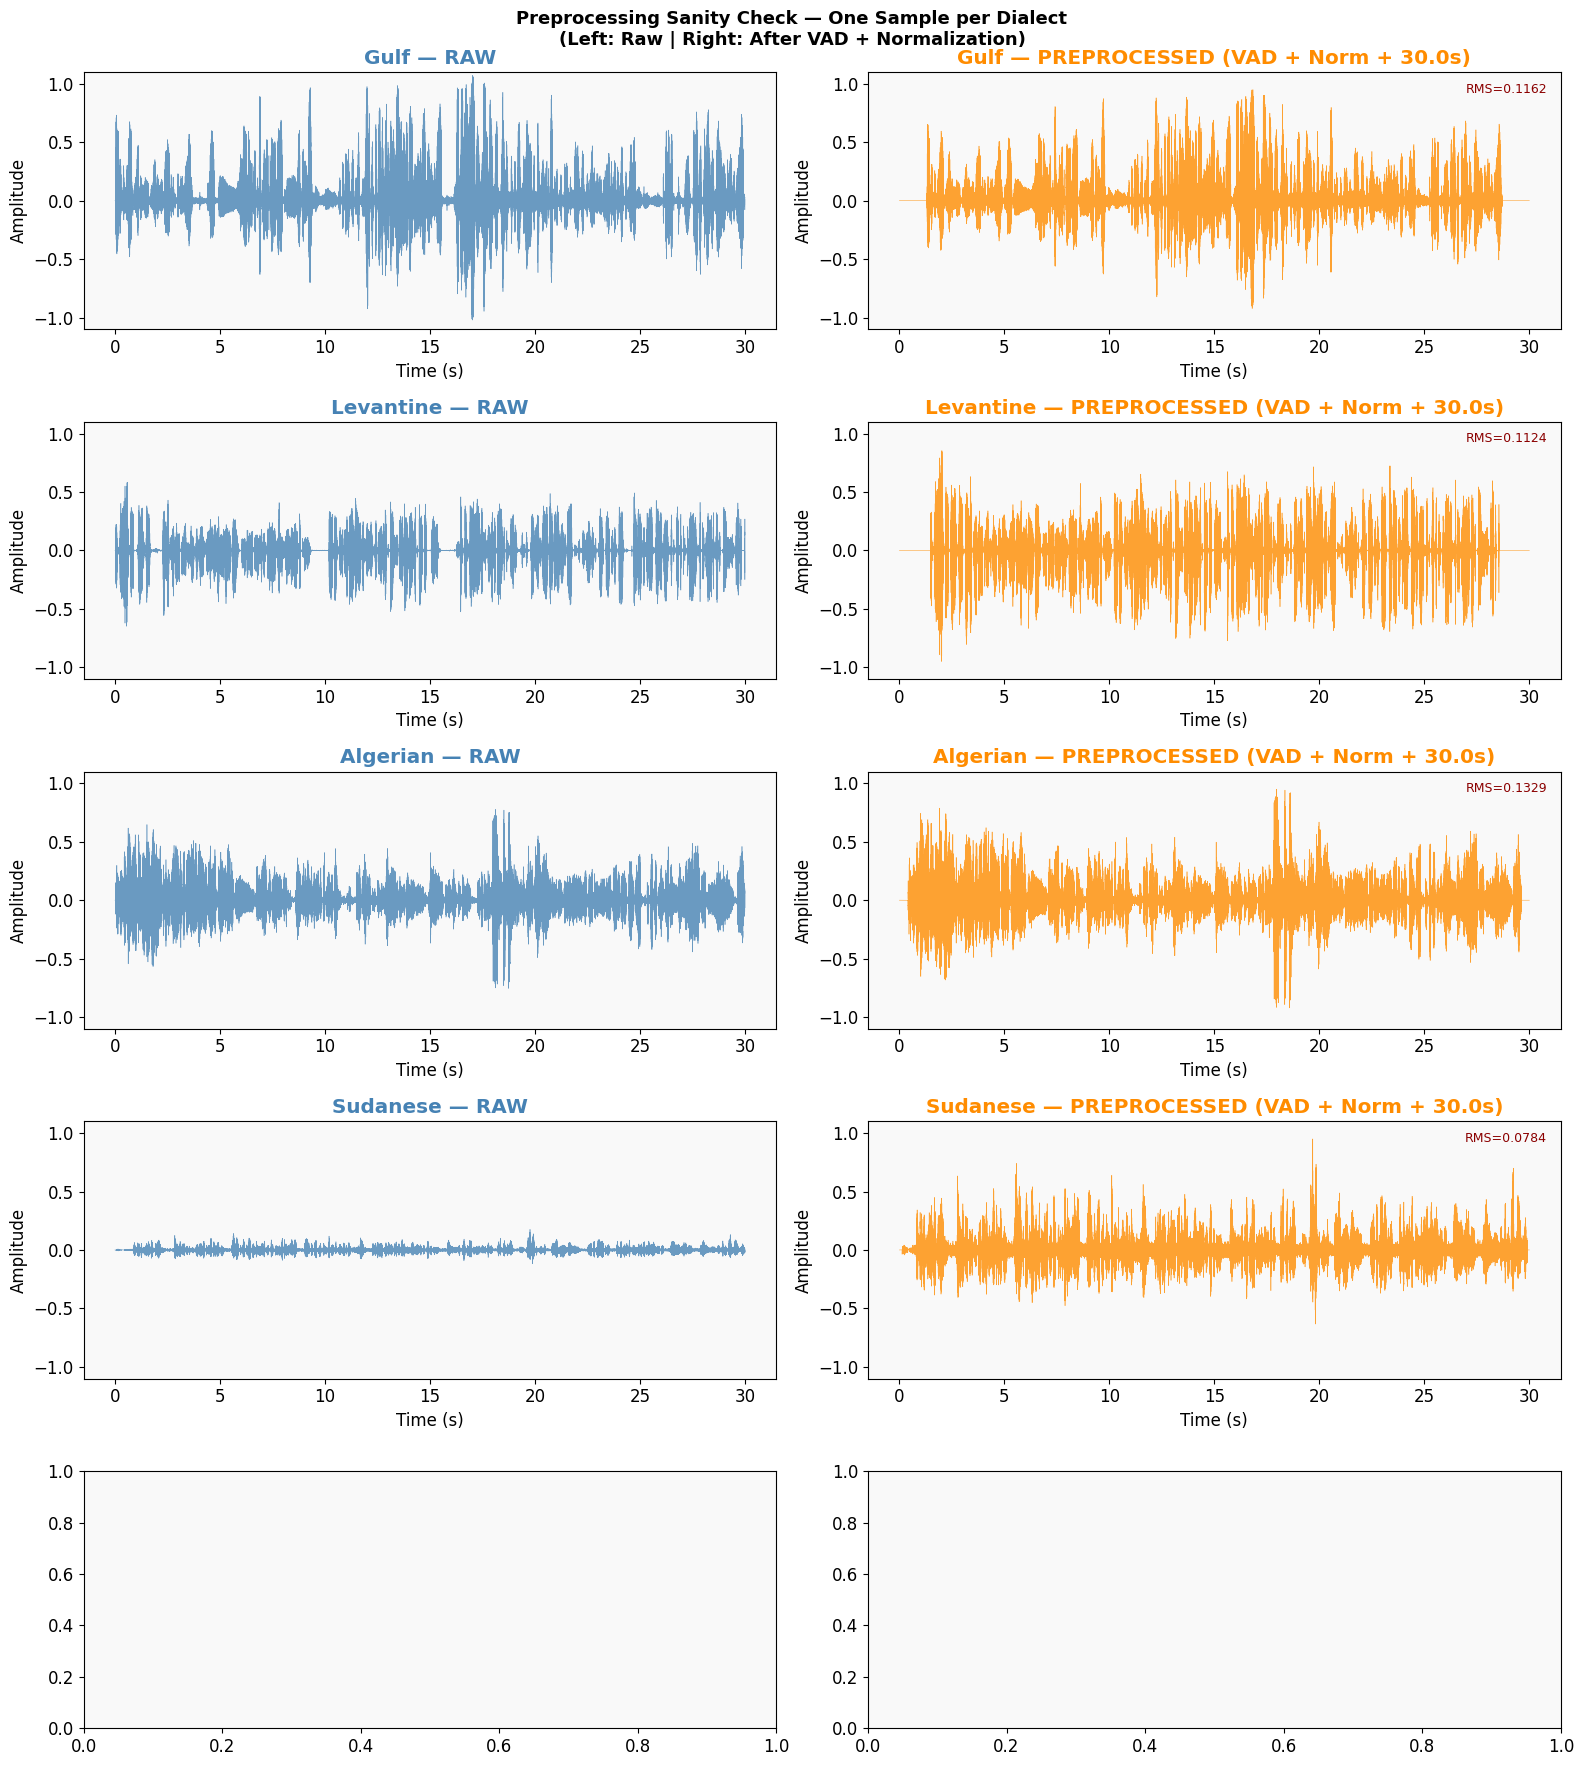

Preprocessing check saved as preprocessing_check.png


In [10]:
# Cell 10: Visually verify preprocessing worked correctly
# Show waveform + VAD effect for one sample per dialect

fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle('Preprocessing Sanity Check — One Sample per Dialect\n(Left: Raw | Right: After VAD + Normalization)',
             fontsize=13, fontweight='bold')

dialect_order = ['Gulf', 'Levantine', 'Algerian', 'Sudanese']

# Get one example per dialect from processed_records
dialect_examples = {}
for record in processed_records:
    d = record['dialect_group']
    if d not in dialect_examples:
        dialect_examples[d] = record

# Also get the raw version for comparison
filename_to_raw = {}
for sample in ds:
    if sample['filename'] in [dialect_examples[d]['filename']
                               for d in dialect_order if d in dialect_examples]:
        filename_to_raw[sample['filename']] = sample['audio']
    if len(filename_to_raw) == len(dialect_order):
        break

for i, dialect in enumerate(dialect_order):
    if dialect not in dialect_examples:
        continue

    record   = dialect_examples[dialect]
    fname    = record['filename']
    waveform = record['waveform']  # preprocessed

    ax_raw  = axes[i, 0]
    ax_proc = axes[i, 1]

    # Raw waveform
    if fname in filename_to_raw:
        raw_audio = np.array(filename_to_raw[fname]['array'], dtype=np.float32)
        raw_sr    = filename_to_raw[fname]['sampling_rate']
        raw_time  = np.linspace(0, len(raw_audio) / raw_sr, len(raw_audio))
        ax_raw.plot(raw_time, raw_audio, color='steelblue', linewidth=0.4, alpha=0.8)
        ax_raw.set_title(f'{dialect} — RAW', fontweight='bold', color='steelblue')
        ax_raw.set_xlabel('Time (s)')
        ax_raw.set_ylabel('Amplitude')
        ax_raw.set_ylim(-1.1, 1.1)

    # Processed waveform
    proc_time = np.linspace(0, TARGET_DURATION, len(waveform))
    ax_proc.plot(proc_time, waveform, color='darkorange', linewidth=0.4, alpha=0.8)
    ax_proc.set_title(f'{dialect} — PREPROCESSED (VAD + Norm + {TARGET_DURATION}s)',
                      fontweight='bold', color='darkorange')
    ax_proc.set_xlabel('Time (s)')
    ax_proc.set_ylabel('Amplitude')
    ax_proc.set_ylim(-1.1, 1.1)

    # Add RMS energy annotation
    rms = np.sqrt(np.mean(waveform**2))
    ax_proc.annotate(f'RMS={rms:.4f}', xy=(0.98, 0.92),
                     xycoords='axes fraction', ha='right',
                     fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig('preprocessing_check.png', dpi=130, bbox_inches='tight')
plt.show()
print("Preprocessing check saved as preprocessing_check.png")

---

## 11 · Feature Extraction

Extract a **123-dimensional acoustic feature vector** from each preprocessed clip.  
Features are designed to capture the phonetic, prosodic, and spectral characteristics that distinguish Arabic dialects.

### Feature Bank

| Feature Family | Count | Description |
|----------------|------:|-------------|
| MFCC 1–13 (mean + std) | 26 | Vocal tract shape |
| Δ-MFCC (mean + std) | 26 | Rate of MFCC change |
| ΔΔ-MFCC (mean + std) | 26 | Acceleration of MFCC |
| Spectral shape (centroid, BW, rolloff, flatness) | 8 | Brightness / sharpness |
| ZCR + RMS (mean + std) | 4 | Energy & noisiness |
| Chroma STFT (12 bins, mean) | 12 | Pitch class distribution |
| Spectral contrast (7 sub-bands, mean) | 7 | Harmonic vs. noise ratio |
| Mel sub-band energies (8 bands, mean) | 8 | Coarse spectral shape |
| Pitch / F0 via YIN | 4 | Mean, std, range, voiced ratio |
| Spectral entropy | 1 | Disorder in frequency content |
| Speaking-rate proxy | 1 | Voiced/unvoiced transitions per second |
| **Total** | **123** | |



In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FAST Expanded Feature Extraction (~123 features)      ║
# ║                                                                  ║
# ║  Speed fixes vs the slow version:                                ║
# ║    1. pyin  → yin (10-20x faster, still good F0 estimate)        ║
# ║    2. Shared STFT computed ONCE, reused by all spectral features ║
# ║    3. joblib Parallel across all CPU cores                       ║
# ║    4. hop_length=512 → hop_length=256 only where needed          ║
# ║    5. n_fft=1024 instead of default 2048 (halves STFT cost)      ║
# ║                                                                  ║
# ║  Expected runtime: ~8-15 min on Kaggle CPU (was ~2 hours)        ║
# ║                                                                  ║
# ║  Feature bank (123 total):                                       ║
# ║    MFCC 1-13         mean + std          →  26                   ║
# ║    Δ-MFCC 1-13       mean + std          →  26                   ║
# ║    ΔΔ-MFCC 1-13      mean + std          →  26                   ║
# ║    Spectral shape    centroid/bw/rolloff/flatness mean+std →  8  ║
# ║    ZCR + RMS         mean + std          →   4                   ║
# ║    Chroma STFT 12    mean                →  12                   ║
# ║    Spectral contrast 7  mean             →   7                   ║
# ║    Mel sub-band (8)  mean                →   8                   ║
# ║    Pitch / F0        mean, std, range, voiced_ratio → 4          ║
# ║    Spectral entropy  1 scalar            →   1                   ║
# ║    Speaking-rate     1 scalar            →   1                   ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import librosa
from sklearn.preprocessing import LabelEncoder
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

assert len(processed_records) > 0, (
    'processed_records is empty! Re-run Cell 10 (preprocessing) first.'
)

# ── Shared STFT / analysis constants ─────────────────────────────────
SR          = 16000
N_FFT       = 1024    # default is 2048 — halves cost, still fine for 16kHz speech
HOP_LENGTH  = 256     # smaller hop only where it matters (delta accuracy)
N_MFCC      = 13
N_MELS      = 8       # mel sub-bands for energy features


# ── Feature-name list ─────────────────────────────────────────────────
def _build_feature_names():
    names = []
    for prefix in ['mfcc', 'delta_mfcc', 'delta2_mfcc']:
        for i in range(1, N_MFCC + 1):
            names += [f'{prefix}_{i:02d}_mean', f'{prefix}_{i:02d}_std']
    for feat in ['spectral_centroid', 'spectral_bandwidth',
                 'spectral_rolloff', 'spectral_flatness', 'zcr', 'rms']:
        names += [f'{feat}_mean', f'{feat}_std']
    for i in range(1, 13):
        names.append(f'chroma_{i:02d}_mean')
    for i in range(1, 8):
        names.append(f'spectral_contrast_{i}_mean')
    for i in range(1, N_MELS + 1):
        names.append(f'mel_band_{i:02d}_mean')
    names += ['f0_mean', 'f0_std', 'f0_range', 'voiced_ratio']
    names += ['spectral_entropy', 'speaking_rate']
    return names

FEATURE_NAMES = _build_feature_names()
print(f'Feature bank size: {len(FEATURE_NAMES)}')


# ── Core extractor — ONE clip, fully vectorized ───────────────────────
def extract_features_fast(waveform, sr=SR):
    """
    Extract all 123 features from one waveform.
    Key optimizations:
      - Single shared STFT (D) computed once and reused
      - YIN pitch instead of pYIN (10-20x faster, comparable accuracy for dialects)
      - All librosa calls share the same n_fft / hop_length
    Returns: np.ndarray of shape (123,) or None on hard failure.
    """
    y = np.ascontiguousarray(waveform, dtype=np.float32)

    # ── Shared STFT (computed ONCE) ───────────────────────────────────
    D      = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    D_mag  = np.abs(D)                    # magnitude spectrogram
    D_pow  = D_mag ** 2                   # power spectrogram

    vec = []

    # ── MFCC + Δ + ΔΔ (78 features) ──────────────────────────────────
    # Pass pre-computed power spectrogram to avoid re-running STFT
    mfcc   = librosa.feature.mfcc(S=librosa.power_to_db(D_pow), n_mfcc=N_MFCC, sr=sr)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    for mat in (mfcc, delta, delta2):
        for row in mat:
            vec += [float(row.mean()), float(row.std())]

    # ── Spectral shape (8 features) ───────────────────────────────────
    # Pass D_mag directly — no re-STFT needed
    cent = librosa.feature.spectral_centroid(S=D_mag, sr=sr)[0]
    bw   = librosa.feature.spectral_bandwidth(S=D_mag, sr=sr)[0]
    roll = librosa.feature.spectral_rolloff(S=D_mag, sr=sr)[0]
    flat = librosa.feature.spectral_flatness(S=D_mag)[0]

    for f in (cent, bw, roll, flat):
        vec += [float(f.mean()), float(f.std())]

    # ── ZCR (2) ───────────────────────────────────────────────────────
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)[0]
    vec += [float(zcr.mean()), float(zcr.std())]

    # ── RMS (2) ───────────────────────────────────────────────────────
    # frame_length must match n_fft when passing S directly
    rms = librosa.feature.rms(S=D_mag, frame_length=N_FFT)[0]
    vec += [float(rms.mean()), float(rms.std())]

    # ── Chroma (12) ───────────────────────────────────────────────────
    chroma = librosa.feature.chroma_stft(S=D_pow, sr=sr)
    vec += [float(v) for v in chroma.mean(axis=1)]

    # ── Spectral contrast (7) ─────────────────────────────────────────
    contrast = librosa.feature.spectral_contrast(S=D_mag, sr=sr)
    vec += [float(v) for v in contrast.mean(axis=1)]

    # ── Mel sub-band energies (8) ─────────────────────────────────────
    mel_spec = librosa.feature.melspectrogram(S=D_pow, sr=sr, n_mels=N_MELS)
    mel_db   = librosa.power_to_db(mel_spec)
    vec += [float(row.mean()) for row in mel_db]

    # ── Pitch / F0 via YIN (4 features) ──────────────────────────────
    # YIN = deterministic autocorrelation — ~15x faster than pYIN.
    # For dialect classification (not speaker ID), YIN is sufficient.
    try:
        # frame_length=512 keeps it fast; fmin/fmax cover adult speech
        f0 = librosa.yin(y, fmin=60.0, fmax=400.0,
                         sr=sr, frame_length=512, hop_length=HOP_LENGTH)
        # YIN returns 0 for unvoiced frames — threshold to detect voiced
        voiced_mask  = f0 > 60.0
        f0_voiced    = f0[voiced_mask]
        voiced_ratio = float(voiced_mask.mean())

        if len(f0_voiced) > 0:
            f0_mean  = float(f0_voiced.mean())
            f0_std   = float(f0_voiced.std())
            f0_range = float(f0_voiced.max() - f0_voiced.min())
        else:
            f0_mean, f0_std, f0_range = 0.0, 0.0, 0.0
    except Exception:
        f0_mean, f0_std, f0_range, voiced_ratio = 0.0, 0.0, 0.0, 0.0

    vec += [f0_mean, f0_std, f0_range, voiced_ratio]

    # ── Spectral entropy (1) ──────────────────────────────────────────
    # Reuse D_pow — no extra computation
    ps_norm = D_pow / (D_pow.sum(axis=0, keepdims=True) + 1e-10)
    sp_ent  = float(-np.sum(ps_norm * np.log2(ps_norm + 1e-10), axis=0).mean())
    vec.append(sp_ent)

    # ── Speaking-rate proxy (1) ───────────────────────────────────────
    # Voiced/unvoiced transitions per second (RMS-energy-based, faster than pYIN)
    try:
        rms_frames   = librosa.feature.rms(S=D_mag)[0]
        rms_thresh   = rms_frames.mean() * 0.5
        voiced_rms   = (rms_frames > rms_thresh).astype(int)
        transitions  = int(np.sum(np.diff(voiced_rms) == 1))
        speak_rate   = float(transitions) / (len(y) / sr)
    except Exception:
        speak_rate = 0.0
    vec.append(speak_rate)

    return np.array(vec, dtype=np.float32)


# ── Worker function for parallel execution ────────────────────────────
def _worker(rec):
    """Process one record. Returns (feature_vector, dialect) or (None, None)."""
    try:
        feats = extract_features_fast(rec['waveform'], sr=SR)
        return feats, rec['dialect_group']
    except Exception:
        return None, None


# ── Dry-run before launching parallel jobs ────────────────────────────
print('\nDry-run on first clip ...')
try:
    test_vec = extract_features_fast(processed_records[0]['waveform'], sr=SR)
    print(f'  Vector length: {len(test_vec)}  (expected: {len(FEATURE_NAMES)})')
    assert len(test_vec) == len(FEATURE_NAMES), \
        f"Length mismatch: got {len(test_vec)}, expected {len(FEATURE_NAMES)}"
    print('  Dry-run OK ✓')
except Exception as e:
    raise RuntimeError(f'Feature extraction failed on first clip: {e}') from e


# ── Parallel extraction ───────────────────────────────────────────────
# n_jobs=-1 uses all available cores.
# prefer='threads' avoids GIL issues with numpy; each clip is independent.
# Kaggle gives 4 cores → ~4x speedup over sequential.
import os
N_JOBS = os.cpu_count() or 4
print(f'\nLaunching parallel extraction on {N_JOBS} CPU cores ...')
print(f'  Clips to process : {len(processed_records)}')
print(f'  Estimated time   : {len(processed_records) / (N_JOBS * 4.5) / 60:.0f}–'
      f'{len(processed_records) / (N_JOBS * 3.0) / 60:.0f} min\n')

results = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=5)(
    delayed(_worker)(rec) for rec in processed_records
)

# ── Collect results ───────────────────────────────────────────────────
X_list, y_list, n_errors = [], [], 0

for feats, dialect in results:
    if feats is None:
        n_errors += 1
    else:
        X_list.append(feats)
        y_list.append(dialect)

if n_errors > 0:
    print(f'\nSkipped {n_errors} clips due to extraction errors.')

if len(X_list) == 0:
    raise RuntimeError('Feature extraction produced 0 samples. Check processed_records.')

X_all = np.vstack(X_list)
y_raw = np.array(y_list)
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print(f'\n{"="*50}')
print(f'  Extraction complete')
print(f'  Feature matrix : {X_all.shape}')
print(f'  Classes        : {list(le.classes_)}')
print(f'  Errors skipped : {n_errors}')
print(f'{"="*50}')

print('\nFeature family breakdown:')
families = {
    'MFCC (mean+std)':       [n for n in FEATURE_NAMES if n.startswith('mfcc_')],
    'Δ-MFCC (mean+std)':     [n for n in FEATURE_NAMES if n.startswith('delta_mfcc_')],
    'ΔΔ-MFCC (mean+std)':    [n for n in FEATURE_NAMES if n.startswith('delta2_mfcc_')],
    'Spectral shape':         [n for n in FEATURE_NAMES if any(k in n for k in
                               ['spectral_centroid','spectral_bandwidth',
                                'spectral_rolloff','spectral_flatness'])],
    'ZCR / RMS':              [n for n in FEATURE_NAMES if n.startswith('zcr') or n.startswith('rms')],
    'Chroma':                 [n for n in FEATURE_NAMES if n.startswith('chroma_')],
    'Spectral contrast':      [n for n in FEATURE_NAMES if n.startswith('spectral_contrast_')],
    'Mel sub-bands':          [n for n in FEATURE_NAMES if n.startswith('mel_band_')],
    'Pitch / F0 (YIN)':       [n for n in FEATURE_NAMES if n.startswith('f0_') or n == 'voiced_ratio'],
    'Entropy / Rate':         [n for n in FEATURE_NAMES if n in ('spectral_entropy','speaking_rate')],
}
for fam, feats in families.items():
    print(f'  {fam:<28}: {len(feats):>3} features')



Feature bank size: 123

Dry-run on first clip ...
  Vector length: 123  (expected: 123)
  Dry-run OK ✓

Launching parallel extraction on 4 CPU cores ...
  Clips to process : 1957
  Estimated time   : 2–3 min



[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    8.0s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   18.4s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:   32.3s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   50.0s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 1144 tasks      | elapsed:  2.2min
[Parallel(n_jobs=4)]: Done 1450 tasks      | elapsed:  2.8min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  3.5min



  Extraction complete
  Feature matrix : (1957, 123)
  Classes        : [np.str_('Algerian'), np.str_('Gulf'), np.str_('Levantine'), np.str_('Sudanese')]
  Errors skipped : 0

Feature family breakdown:
  MFCC (mean+std)             :  26 features
  Δ-MFCC (mean+std)           :  26 features
  ΔΔ-MFCC (mean+std)          :  26 features
  Spectral shape              :   8 features
  ZCR / RMS                   :   4 features
  Chroma                      :  12 features
  Spectral contrast           :   7 features
  Mel sub-bands               :   8 features
  Pitch / F0 (YIN)            :   4 features
  Entropy / Rate              :   2 features


[Parallel(n_jobs=4)]: Done 1957 out of 1957 | elapsed:  3.8min finished


## 12 · Feature Selection

Reduce 123 features → **top-20** using a robust 4-step pipeline:

### Pipeline

```
Step 1 → VarianceThreshold(0.01)      Remove near-constant features
Step 2 → ANOVA F + Mutual Information  Dual-rank scoring
Step 3 → Category budget              Enforce family diversity
Step 4 → Redundancy pruning |r| > 0.80 Remove near-duplicate features
```

### Category Budget

| Family | Max slots |
|--------|----------:|
| MFCC | 5 |
| Δ-MFCC | 3 |
| ΔΔ-MFCC | 3 |
| Spectral Shape | 3 |
| Pitch / F0 | 2 |
| Mel Sub-bands | 2 |
| Spectral Contrast | 1 |
| Chroma | 1 |

A **Cohen's d separability diagnostic** is printed at the end, flagging any feature with d < 0.3 across all dialect pairs.


In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Robust Top-20 Feature Selection  (4-step pipeline)    ║
# ║                                                                  ║
# ║  Step 1 — Near-zero-variance filter (VarianceThreshold)          ║
# ║  Step 2 — ANOVA F + Mutual Information dual-rank scoring         ║
# ║  Step 3 — Category-budget selection (enforces family diversity)  ║
# ║  Step 4 — Tightened redundancy pruning  |r| > 0.70               ║
# ║                                                                  ║
# ║  After selection: Cohen's d dialect-pair overlap diagnostic      ║
# ║  prints a clear separability score for every chosen feature,     ║
# ║  so you can see exactly which features are doing real work.      ║
# ╚══════════════════════════════════════════════════════════════════════╝
 
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
 
assert 'X_all' in globals(), "Run Cell 12 first — X_all must exist."
 
print("=" * 65)
print("  ROBUST TOP-20 FEATURE SELECTION  (4-step pipeline)")
print("=" * 65)
 
 
# ── Step 1: Near-zero-variance filter ────────────────────────────────
print("\n[Step 1] Removing near-zero-variance features (threshold=0.01) ...")
vt        = VarianceThreshold(threshold=0.01)
X_vt      = vt.fit_transform(X_all)
vt_mask   = vt.get_support(indices=True)          # original indices that survived
vt_names  = [FEATURE_NAMES[i] for i in vt_mask]
print(f"  {X_all.shape[1]} → {X_vt.shape[1]} features after variance filter")
 
 
# ── Step 2: ANOVA F + Mutual Information dual-rank scoring ───────────
print("\n[Step 2] Computing ANOVA F-scores ...")
f_scores, _ = f_classif(X_vt, y_enc)
f_scores    = np.nan_to_num(f_scores, nan=0.0)
 
print("         Computing Mutual Information scores (n_neighbors=5) ...")
mi_scores = mutual_info_classif(
    X_vt, y_enc,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)
 
# Rank: 1 = best.  Use average of the two rank vectors.
f_rank  = pd.Series(f_scores,  index=vt_names).rank(ascending=False)
mi_rank = pd.Series(mi_scores, index=vt_names).rank(ascending=False)
agg_rank = ((f_rank + mi_rank) / 2.0).sort_values()
 
print("\n  Top-30 candidates by aggregated rank-sum (F + MI):")
print(f"  {'Rank':>4}  {'Feature':<40}  {'F-score':>9}  {'MI-score':>9}  {'Avg-rank':>9}")
print("  " + "─" * 75)
for k, (feat, avg_r) in enumerate(agg_rank.head(30).items(), 1):
    fi = f_scores[vt_names.index(feat)]
    mi = mi_scores[vt_names.index(feat)]
    print(f"  {k:>4}  {feat:<40}  {fi:>9.2f}  {mi:>9.4f}  {avg_r:>9.1f}")
 
 
# ── Step 3: Category-budget selection ────────────────────────────────
# Each family contributes at most its budget to the final 20.
# This prevents MFCC features crowding out F0, ΔΔ-MFCC, etc.
print("\n[Step 3] Applying category budget ...")
 
CATEGORY_BUDGET = {
    'MFCC':             5,
    'Δ-MFCC':           3,
    'ΔΔ-MFCC':          3,
    'Spectral Shape':   3,
    'Pitch/F0':         2,
    'Mel Sub-bands':    2,
    'Spectral Contrast':1,
    'Chroma':           1,
}
# Any remaining budget slots go to the best-ranked features overall
 
def _get_category(name):
    if name.startswith('mfcc_'):                           return 'MFCC'
    if name.startswith('delta_mfcc_'):                     return 'Δ-MFCC'
    if name.startswith('delta2_mfcc_'):                    return 'ΔΔ-MFCC'
    if any(k in name for k in ['spectral_centroid',
           'spectral_bandwidth','spectral_rolloff',
           'spectral_flatness','zcr','rms']):              return 'Spectral Shape'
    if name.startswith('f0_') or name == 'voiced_ratio':  return 'Pitch/F0'
    if name.startswith('mel_band_'):                       return 'Mel Sub-bands'
    if name.startswith('spectral_contrast_'):             return 'Spectral Contrast'
    if name.startswith('chroma_'):                         return 'Chroma'
    return 'Other'
 
category_counts   = {k: 0 for k in CATEGORY_BUDGET}
category_counts['Other'] = 0
budget_selected   = []
 
# Iterate features in rank order; fill each category up to its budget
for feat in agg_rank.index:
    cat = _get_category(feat)
    cap = CATEGORY_BUDGET.get(cat, 2)         # 'Other' gets up to 2
    if category_counts.get(cat, 0) < cap:
        budget_selected.append(feat)
        category_counts[cat] = category_counts.get(cat, 0) + 1
    if len(budget_selected) >= 50:            # keep a pool of 50 for step 4
        break
 
# Fallback: if budget gives < 20, backfill from rank order regardless of category
if len(budget_selected) < 20:
    print(f"  \u26a0 Budget pool only {len(budget_selected)} — backfilling from rank order ...")
    for feat in agg_rank.index:
        if feat not in budget_selected:
            budget_selected.append(feat)
        if len(budget_selected) >= 50:
            break
 
print("  Category slots filled:")
for cat, cnt in category_counts.items():
    if cnt > 0:
        print(f"    {cat:<20}: {cnt}")
print(f"  Pool for redundancy pruning: {len(budget_selected)} features")
 
 
# ── Step 4: Tightened redundancy pruning |r| > 0.70 ──────────────────
# Much stricter than the original 0.85 — features with |r|=0.84 are
# nearly identical and waste a slot in the final 20.
print("\n[Step 4] Redundancy pruning (|r| > 0.70) ...")
 
scaler      = StandardScaler()
X_pool_std  = scaler.fit_transform(X_vt[:, [vt_names.index(f) for f in budget_selected]])
 
selected   = []
rejected   = {}
 
for i, feat in enumerate(budget_selected):
    col = X_pool_std[:, i]
    redundant_with = None
    for sel in selected:
        j   = budget_selected.index(sel)
        r   = float(np.corrcoef(col, X_pool_std[:, j])[0, 1])
        if abs(r) > 0.80:
            redundant_with = (sel, round(r, 3))
            break
    if redundant_with is None:
        selected.append(feat)
        if len(selected) == 20:
            break
    else:
        rejected[feat] = redundant_with
 
print(f"  Pruned {len(rejected)} redundant feature(s):")
for feat, (corr_with, r) in rejected.items():
    print(f"    ✗  {feat:<40}  |r|={abs(r):.3f} with '{corr_with}'")
 
 
# ── Build final top20_df ─────────────────────────────────────────────
top20_rows = []
for rank20, feat in enumerate(selected, 1):
    pool_idx  = vt_names.index(feat)
    orig_idx  = int(vt_mask[pool_idx])
    top20_rows.append({
        'rank_top20'   : rank20,
        'feature'      : feat,
        'category'     : _get_category(feat),
        'F_score'      : round(float(f_scores[pool_idx]), 2),
        'MI_score'     : round(float(mi_scores[pool_idx]), 4),
        'agg_rank'     : round(float(agg_rank[feat]), 1),
        'original_idx' : orig_idx,
    })
 
top20_df = pd.DataFrame(top20_rows)
 
print("\n" + "=" * 65)
print("  FINAL TOP-20 FEATURES")
print("=" * 65)
print(f"  {'#':>3}  {'Feature':<40}  {'Cat':<18}  {'F-score':>8}  {'MI':>7}  {'Rank':>6}")
print("  " + "─" * 82)
for _, row in top20_df.iterrows():
    print(f"  {int(row['rank_top20']):>3}  {row['feature']:<40}  "
          f"{row['category']:<18}  {row['F_score']:>8.2f}  "
          f"{row['MI_score']:>7.4f}  {row['agg_rank']:>6.1f}")
 
# ── Build X_top20 ─────────────────────────────────────────────────────
selected_orig_idx = top20_df['original_idx'].values
X_top20 = X_all[:, selected_orig_idx]
print(f"\nX_top20 shape: {X_top20.shape}  — ready for modelling.")
 
 
# ── Cohen's d dialect-pair separability diagnostic ───────────────────
# For every feature, compute Cohen's d between all 6 dialect pairs.
# A feature with d < 0.3 for ALL pairs adds noise, not signal.
print("\n" + "=" * 65)
print("  COHEN'S d SEPARABILITY DIAGNOSTIC")
print("  (d < 0.3 for ALL pairs = weak feature | d > 0.8 = strong)")
print("=" * 65)
 
feat_names_20 = top20_df['feature'].values
label_names   = le.inverse_transform(y_enc)
DIALECTS      = sorted(le.classes_)
 
X_top20_std = StandardScaler().fit_transform(X_top20)
 
weak_features = []
for fi, fname in enumerate(feat_names_20):
    col    = X_top20_std[:, fi]
    d_vals = {}
    for d1, d2 in combinations(DIALECTS, 2):
        x1   = col[label_names == d1]
        x2   = col[label_names == d2]
        denom = np.sqrt((x1.std()**2 + x2.std()**2) / 2)
        d     = abs(x1.mean() - x2.mean()) / (denom + 1e-10)
        d_vals[f'{d1[:3]}vs{d2[:3]}'] = round(float(d), 3)
 
    max_d  = max(d_vals.values())
    weak   = "⚠ WEAK" if max_d < 0.3 else ""
    if max_d < 0.3:
        weak_features.append(fname)
 
    pair_str = "  ".join([f"{k}={v:.2f}" for k, v in d_vals.items()])
    print(f"\n  {fi+1:>2}. {fname}")
    print(f"      {pair_str}  {weak}")
 
if weak_features:
    print(f"\n  ⚠  {len(weak_features)} feature(s) are weak separators across ALL dialect pairs:")
    for wf in weak_features:
        print(f"     → {wf}  (consider replacing in next iteration)")
else:
    print("\n  ✓  All 20 features have Cohen's d ≥ 0.3 for at least one dialect pair.")
 

 

  ROBUST TOP-20 FEATURE SELECTION  (4-step pipeline)

[Step 1] Removing near-zero-variance features (threshold=0.01) ...
  123 → 78 features after variance filter

[Step 2] Computing ANOVA F-scores ...
         Computing Mutual Information scores (n_neighbors=5) ...

  Top-30 candidates by aggregated rank-sum (F + MI):
  Rank  Feature                                     F-score   MI-score   Avg-rank
  ───────────────────────────────────────────────────────────────────────────
     1  mel_band_03_mean                             145.04     0.3775        4.5
     2  spectral_flatness_std                        159.97     0.3513        5.0
     3  mel_band_04_mean                             136.52     0.3732        6.5
     4  mfcc_02_std                                  182.58     0.3201        8.5
     5  spectral_bandwidth_std                       146.38     0.3440        8.5
     6  mel_band_05_mean                             129.79     0.3615       11.0
     7  mel_band_06_mean   

---

## 12b · Post-Selection Cleanup

Drop any feature whose **maximum Cohen's d** across all 6 dialect pairs falls below 0.3.  
Such features add noise rather than signal to classical ML models.

> Threshold: `max Cohen's d ≥ 0.30` for at least one dialect pair.


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 12b — Post-Selection Cleanup                               ║
# ║                                                                  ║
# ║  Drops any feature flagged as weak (max Cohen's d < 0.3 across   ║
# ║  all dialect pairs). No forced replacement — fewer clean features ║               
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.preprocessing import StandardScaler

assert 'X_top20' in globals(), "Run Cell 13 first."

COHENS_D_THRESHOLD = 0.3   # feature must exceed this for at least ONE dialect pair

feat_names_current = top20_df['feature'].values
label_names        = le.inverse_transform(y_enc)
DIALECTS           = sorted(le.classes_)
X_std_current      = StandardScaler().fit_transform(X_top20)

# ── Compute max Cohen's d per feature ────────────────────────────────
def max_cohens_d(col, label_names, dialects):
    best = 0.0
    for d1, d2 in combinations(dialects, 2):
        x1    = col[label_names == d1]
        x2    = col[label_names == d2]
        denom = np.sqrt((x1.std()**2 + x2.std()**2) / 2)
        d     = abs(x1.mean() - x2.mean()) / (denom + 1e-10)
        if d > best:
            best = d
    return best

print("=" * 60)
print("  FEATURE CLEANUP — dropping weak separators")
print("=" * 60)
print(f"\n  Threshold: max Cohen's d across all pairs ≥ {COHENS_D_THRESHOLD}\n")

keep_mask  = []
drop_list  = []

for fi, fname in enumerate(feat_names_current):
    col   = X_std_current[:, fi]
    max_d = max_cohens_d(col, label_names, DIALECTS)
    if max_d < COHENS_D_THRESHOLD:
        drop_list.append((fname, round(max_d, 3)))
        keep_mask.append(False)
        print(f"  ✗  DROPPING  {fname:<40}  max_d={max_d:.3f}")
    else:
        keep_mask.append(True)

if not drop_list:
    print("  ✓  No weak features found — all features kept.")
else:
    print(f"\n  Dropped {len(drop_list)} feature(s).")

# ── Apply mask ────────────────────────────────────────────────────────
keep_mask = np.array(keep_mask)
top20_df  = top20_df[keep_mask].reset_index(drop=True)
top20_df['rank_top20'] = range(1, len(top20_df) + 1)

selected_orig_idx = top20_df['original_idx'].values
X_top20           = X_all[:, selected_orig_idx]

# ── Final feature summary ─────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"  FINAL CLEAN FEATURE SET  ({len(top20_df)} features)")
print(f"{'=' * 60}")
print(f"  {'#':>3}  {'Feature':<40}  {'Cat':<18}  {'F-score':>8}  {'MI':>7}")
print("  " + "─" * 78)
for _, row in top20_df.iterrows():
    print(f"  {int(row['rank_top20']):>3}  {row['feature']:<40}  "
          f"{row['category']:<18}  {row['F_score']:>8.2f}  {row['MI_score']:>7.4f}")

print(f"\n  X_top20 shape : {X_top20.shape}")
print(f"\n  Category breakdown:")
for cat, grp in top20_df.groupby('category'):
    print(f"    {cat:<20}: {len(grp)} feature(s) — {', '.join(grp['feature'].tolist())}")

print("\n[Next] → Cell 14: visualise the final feature set")

  FEATURE CLEANUP — dropping weak separators

  Threshold: max Cohen's d across all pairs ≥ 0.3

  ✗  DROPPING  f0_range                                  max_d=0.240

  Dropped 1 feature(s).

  FINAL CLEAN FEATURE SET  (11 features)
    #  Feature                                   Cat                  F-score       MI
  ──────────────────────────────────────────────────────────────────────────────
    1  mel_band_03_mean                          Mel Sub-bands         145.04   0.3775
    2  spectral_flatness_std                     Spectral Shape        159.97   0.3513
    3  mfcc_02_std                               MFCC                  182.58   0.3201
    4  delta2_mfcc_09_std                        ΔΔ-MFCC               141.07   0.3189
    5  delta2_mfcc_04_std                        ΔΔ-MFCC               146.21   0.3071
    6  delta_mfcc_02_std                         Δ-MFCC                150.75   0.3050
    7  mfcc_03_mean                              MFCC                   75.69

# 14 · Feature Visualisation

Five publication-quality figures summarising the selected feature set:

| Figure | Content |
|--------|---------|
| **Fig 1** | F-score + MI dual-axis bar chart & Pearson correlation heatmap |
| **Fig 2** | Category donut chart + violin plots (top-5 features) |
| **Fig 3** | Box-plot grid — all selected features × dialect |
| **Fig 4** | Cohen's d heatmap — features × dialect pairs *(key diagnostic)* |
| **Fig 5** | 2D LDA scatter — sanity check for class separability |

All figures saved to disk as `.png` files.


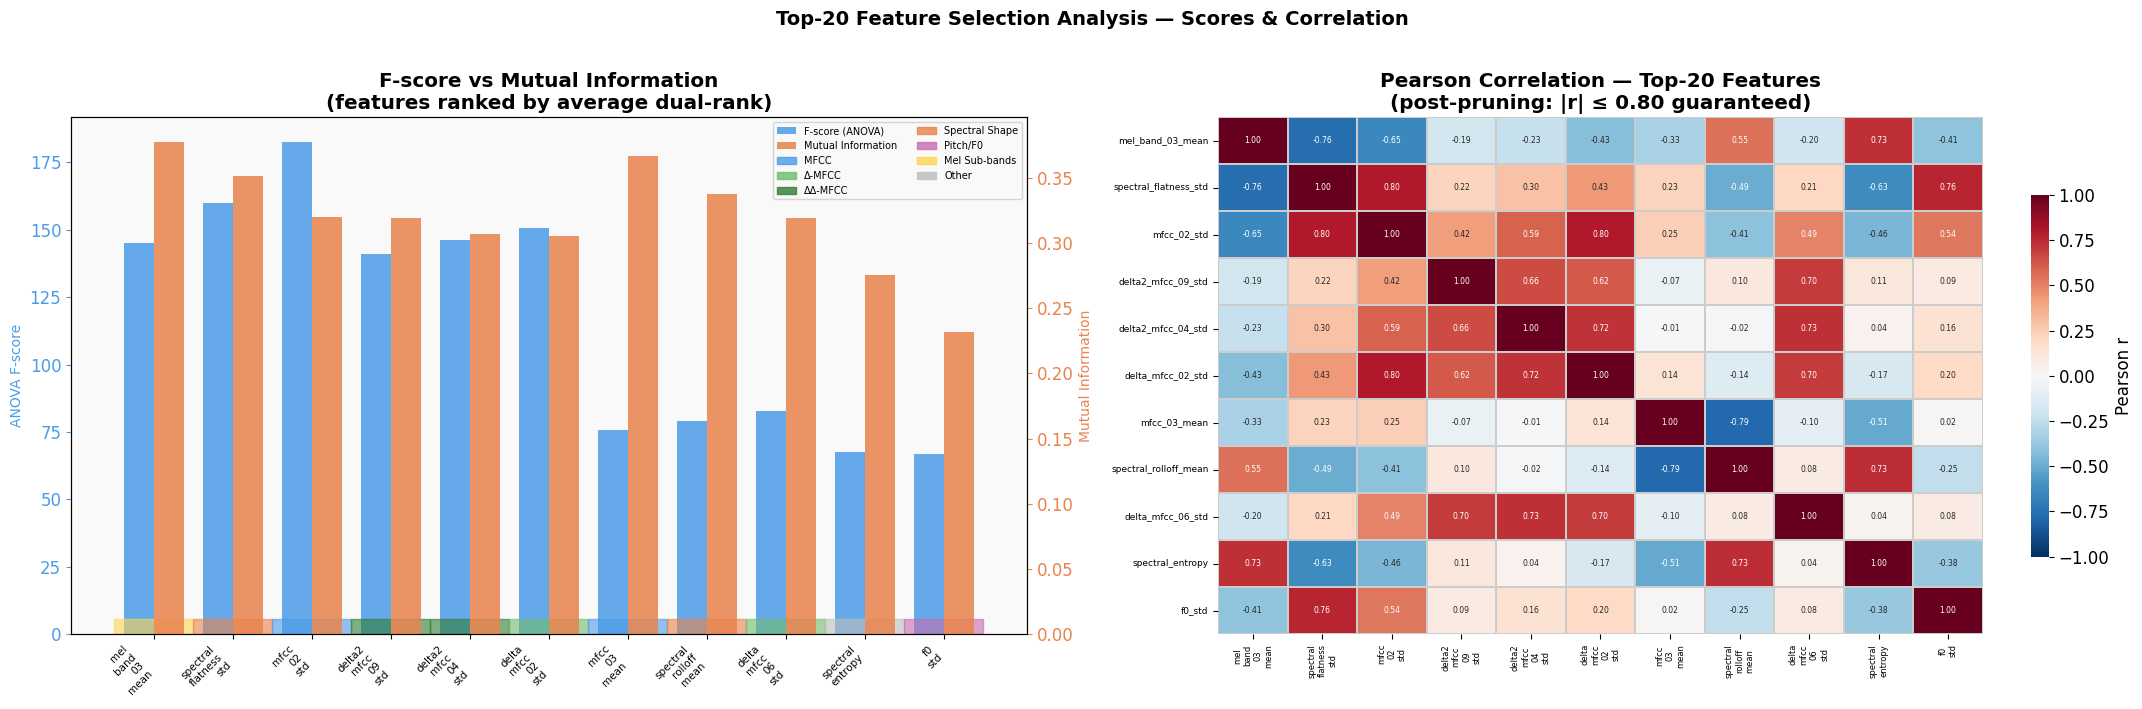

Figure 1 saved → top20_scores_and_corr.png


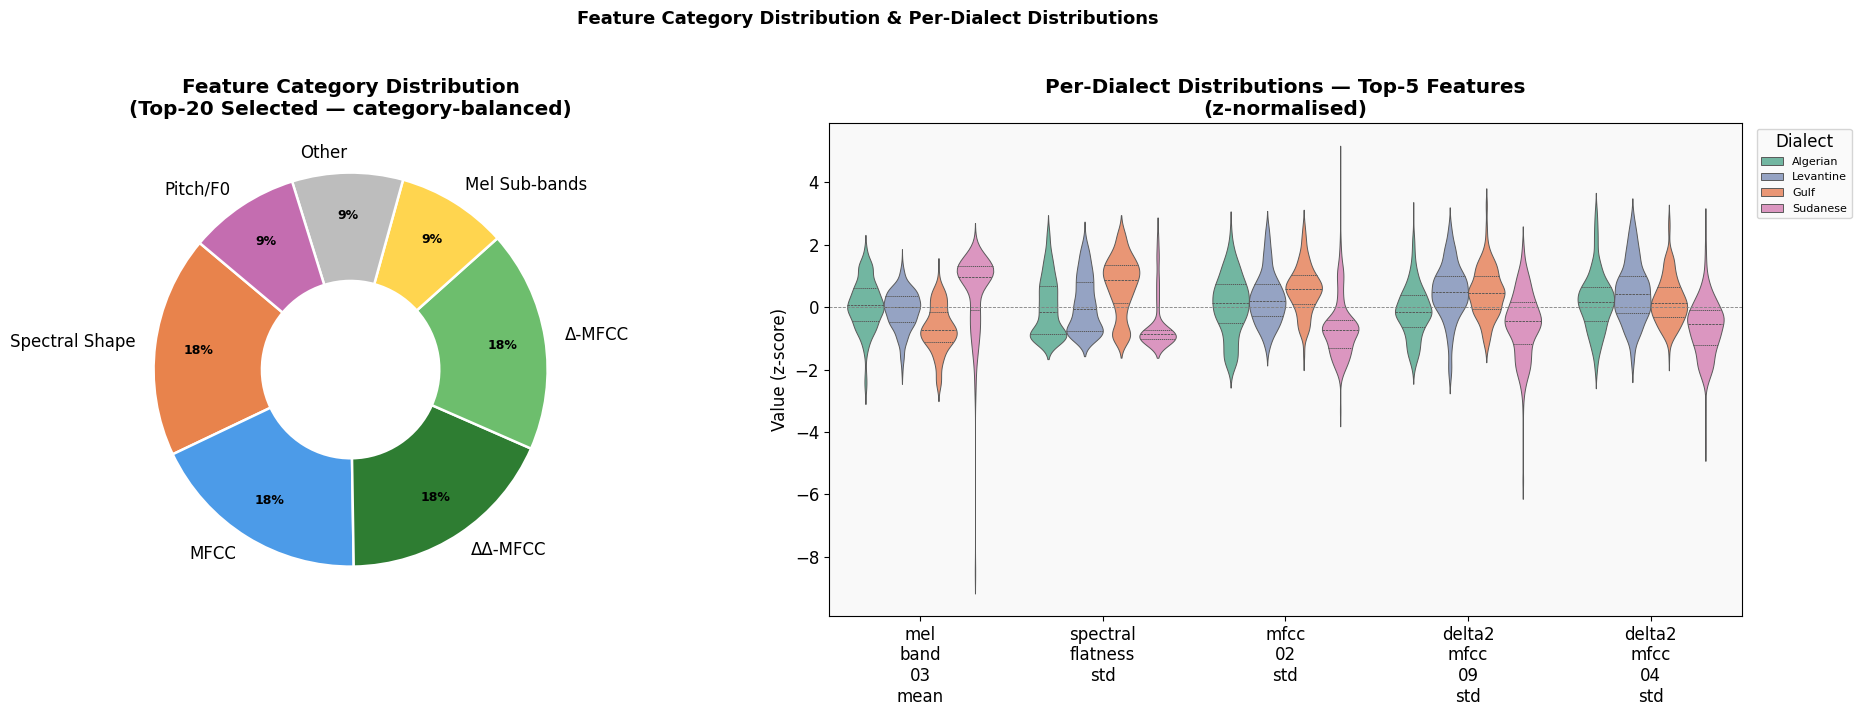

Figure 2 saved → top20_category_violin.png


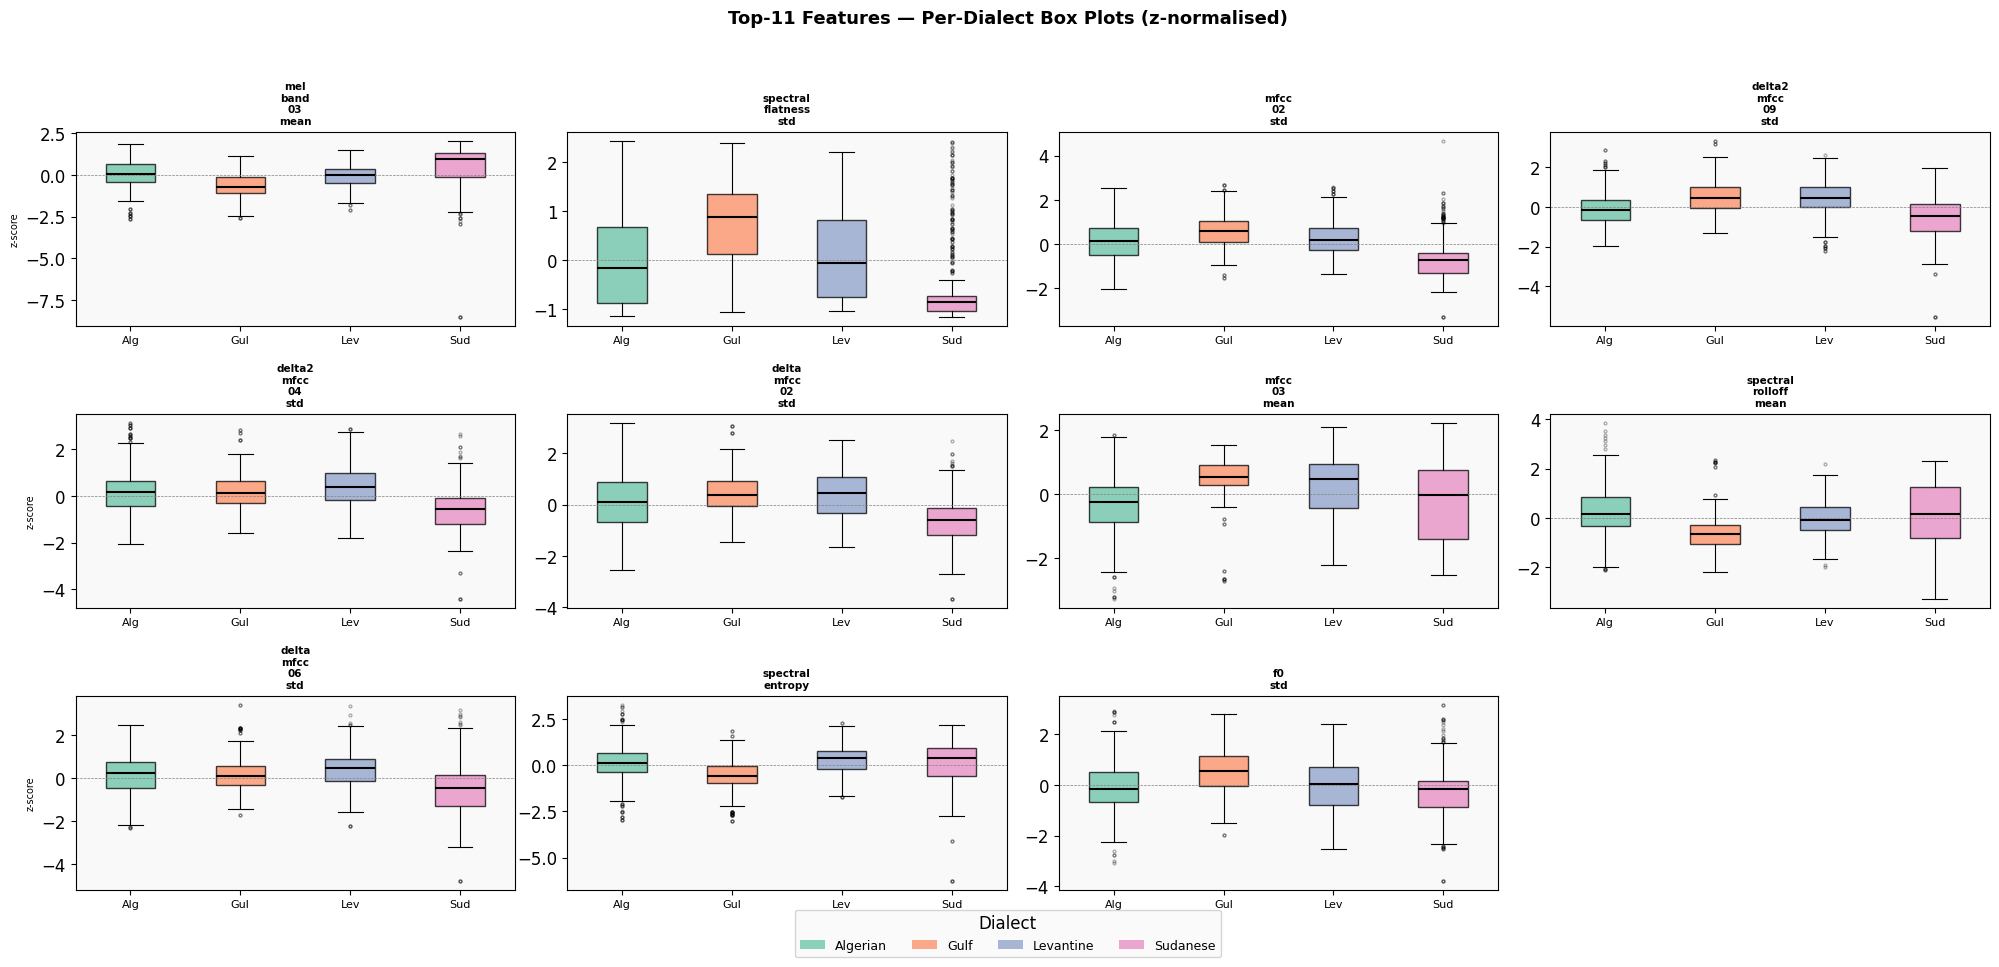

Figure 3 saved → top20_boxplots.png


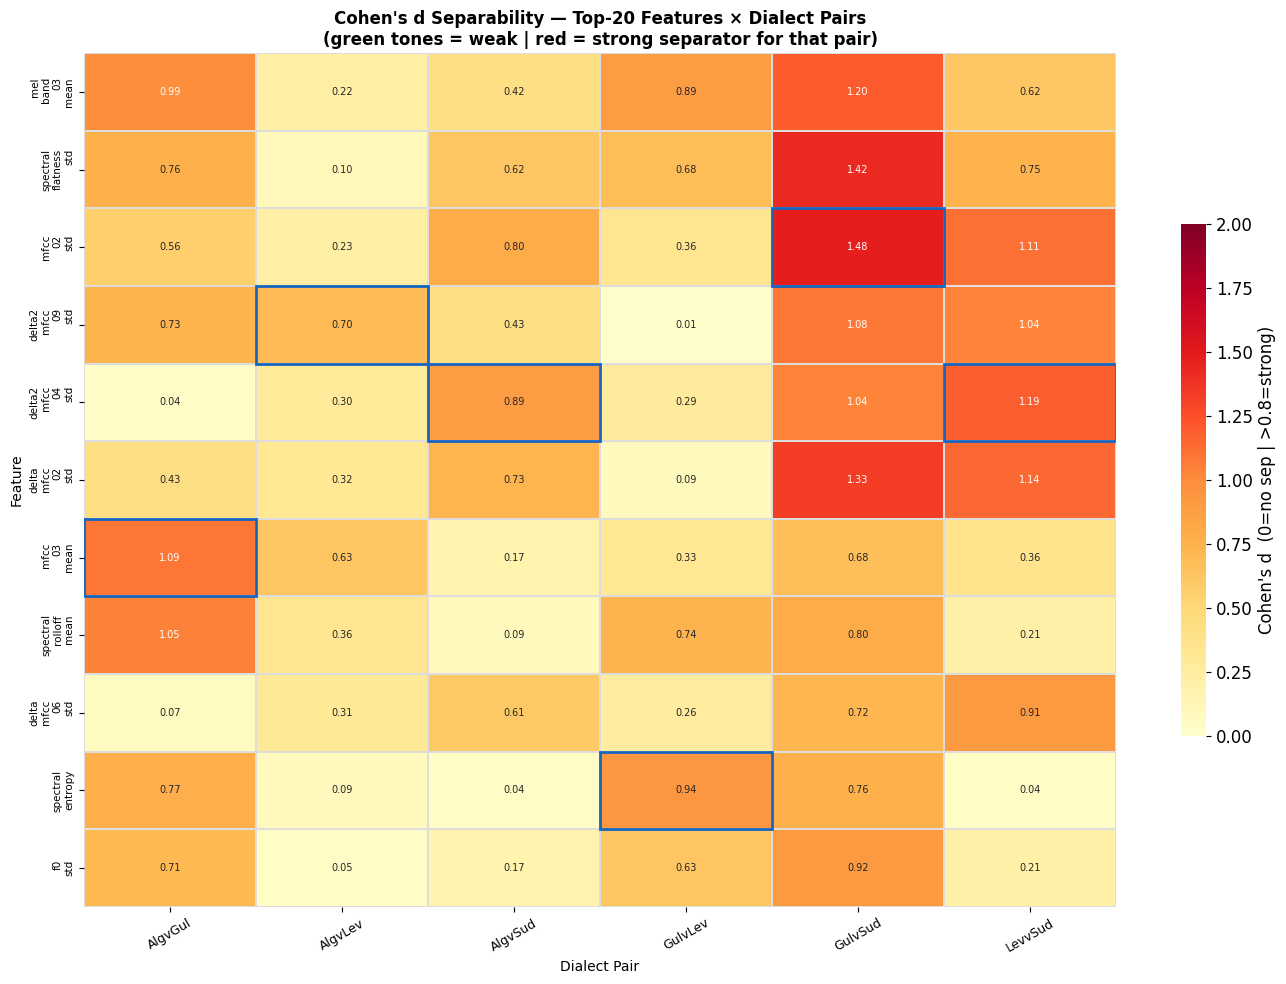

Figure 4 saved → top20_cohens_d_heatmap.png
  Blue border = best separator for each dialect pair.


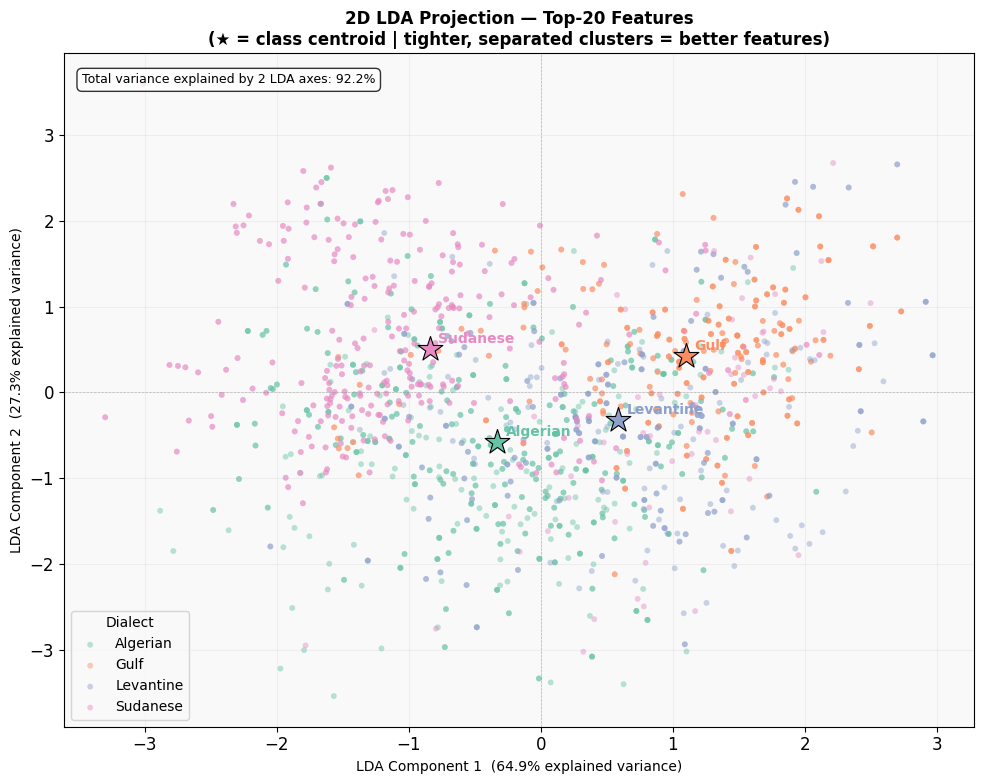

Figure 5 saved → top20_lda_scatter.png

  FEATURE ANALYSIS COMPLETE
  X_top20 shape : (1957, 11)  — ready for modelling.

  Saved figures:
    top20_scores_and_corr.png   — scores + correlation heatmap
    top20_category_violin.png   — category donut + violin plots
    top20_boxplots.png          — box-plot grid (top-12)
    top20_cohens_d_heatmap.png  — separability per dialect pair  ← KEY
    top20_lda_scatter.png       — 2D LDA sanity check            ← KEY

[Next] → Cell 15: stratified train/val/test split


In [14]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Top-20 Feature Visualisation  (5 figures)                ║
# ║                                                                      ║
# ║  Fig 1 — F-score + MI dual-axis bar  +  Pearson correlation heatmap ║
# ║  Fig 2 — Category donut  +  Violin plots (top-5 features)           ║
# ║  Fig 3 — Box-plot grid (top-12 features × dialect)                  ║
# ║  Fig 4 — Cohen's d heatmap: 20 features × 6 dialect pairs          ║
# ║  Fig 5 — 2D LDA scatter (sanity check — are classes separable?)     ║
# ╚══════════════════════════════════════════════════════════════════════╝
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
 
assert 'X_top20' in globals(), "Run Cell 13 first."
 
# ── Shared setup ─────────────────────────────────────────────────────
DIALECTS    = sorted(le.classes_)
PALETTE     = dict(zip(DIALECTS, sns.color_palette("Set2", len(DIALECTS))))
feat_names  = top20_df['feature'].values
label_names = le.inverse_transform(y_enc)
 
X_std = StandardScaler().fit_transform(X_top20)
 
 
# ═════════════════════════════════════════════════════════════════════
# FIGURE 1 — Selection scores + Correlation heatmap
# ═════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 2, figsize=(22, 7))
fig1.suptitle('Top-20 Feature Selection Analysis — Scores & Correlation',
              fontsize=14, fontweight='bold', y=1.01)
 
# Panel A: Dual-axis grouped bar (F-score + MI)
ax   = axes1[0]
ax2  = ax.twinx()
x    = np.arange(len(feat_names))
w    = 0.38
 
bars1 = ax.bar(x - w/2, top20_df['F_score'],  w,
               color='#4C9BE8', alpha=0.85, label='F-score (ANOVA)')
bars2 = ax2.bar(x + w/2, top20_df['MI_score'], w,
                color='#E8834C', alpha=0.85, label='Mutual Information')
 
ax.set_xticks(x)
ax.set_xticklabels(
    [n.replace('_', '\n') for n in feat_names],
    rotation=45, ha='right', fontsize=7.5
)
ax.set_ylabel('ANOVA F-score',      color='#4C9BE8', fontsize=10)
ax2.set_ylabel('Mutual Information', color='#E8834C', fontsize=10)
ax.tick_params(axis='y', colors='#4C9BE8')
ax2.tick_params(axis='y', colors='#E8834C')
ax.set_title('F-score vs Mutual Information\n(features ranked by average dual-rank)',
             fontweight='bold')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)
 
# Category color strip below bars
cat_colors_map = {
    'MFCC':             '#4C9BE8',
    'Δ-MFCC':           '#6DBE6D',
    'ΔΔ-MFCC':          '#2E7D32',
    'Spectral Shape':   '#E8834C',
    'Pitch/F0':         '#C46DB0',
    'Mel Sub-bands':    '#FFD54F',
    'Spectral Contrast':'#8D6E63',
    'Chroma':           '#78909C',
    'Other':            '#BDBDBD',
}
for xi, cat in zip(x, top20_df['category']):
    ax.axvspan(xi - 0.5, xi + 0.5, ymin=0, ymax=0.03,
               color=cat_colors_map.get(cat, '#BDBDBD'), alpha=0.6)
 
# Panel B: Pearson correlation heatmap
ax_hm = axes1[1]
corr  = pd.DataFrame(X_std, columns=feat_names).corr()
sns.heatmap(
    corr, ax=ax_hm,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 5.5},
    linewidths=0.3, linecolor='#cccccc',
    xticklabels=[f.replace('_', '\n') for f in feat_names],
    yticklabels=feat_names,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
ax_hm.set_title('Pearson Correlation — Top-20 Features\n'
                '(post-pruning: |r| ≤ 0.80 guaranteed)',
                fontweight='bold')
ax_hm.tick_params(axis='x', labelsize=6)
ax_hm.tick_params(axis='y', labelsize=6.5)
 
# Category legend
legend_handles = [mpatches.Patch(color=c, label=cat, alpha=0.8)
                  for cat, c in cat_colors_map.items()
                  if cat in top20_df['category'].values]
ax.legend(h1 + h2 + legend_handles,
          l1 + l2 + [h.get_label() for h in legend_handles],
          loc='upper right', fontsize=7, ncol=2)
 
plt.tight_layout()
plt.savefig('top20_scores_and_corr.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure 1 saved → top20_scores_and_corr.png")
 
 
# ═════════════════════════════════════════════════════════════════════
# FIGURE 2 — Category donut + Violin plots (top-5 features)
# ═════════════════════════════════════════════════════════════════════
cat_counts = top20_df['category'].value_counts()
 
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 7))
fig2.suptitle('Feature Category Distribution & Per-Dialect Distributions',
              fontsize=13, fontweight='bold', y=1.02)
 
# Left — donut chart
ax_pie = axes2[0]
wedge_colors = [cat_colors_map.get(c, '#BDBDBD') for c in cat_counts.index]
wedges, texts, autotexts = ax_pie.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.0f%%',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.8)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax_pie.set_title('Feature Category Distribution\n(Top-20 Selected — category-balanced)',
                 fontweight='bold')
 
# Right — violin for top-5 features
ax_vln  = axes2[1]
top5    = feat_names[:5]
vln_rows = []
for i, feat in enumerate(top5):
    for val, dialect in zip(X_std[:, i], label_names):
        vln_rows.append({'Feature': feat.replace('_', '\n'),
                         'Value (z-score)': float(val),
                         'Dialect': dialect})
 
vln_df = pd.DataFrame(vln_rows)
sns.violinplot(
    data=vln_df, x='Feature', y='Value (z-score)', hue='Dialect',
    palette=PALETTE, ax=ax_vln, inner='quartile',
    scale='width', linewidth=0.7
)
ax_vln.set_title('Per-Dialect Distributions — Top-5 Features\n(z-normalised)',
                 fontweight='bold')
ax_vln.legend(title='Dialect', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax_vln.axhline(0, color='grey', lw=0.6, ls='--')
ax_vln.set_xlabel('')
 
plt.tight_layout()
plt.savefig('top20_category_violin.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure 2 saved → top20_category_violin.png")
 
 
# ═════════════════════════════════════════════════════════════════════
# FIGURE 3 — Box-plot grid: all selected features × dialect
# ═════════════════════════════════════════════════════════════════════
n_box  = len(feat_names)   # dynamic: works whether you got 7 or 20
n_cols = min(4, n_box)
n_rows = (n_box + n_cols - 1) // n_cols   # ceiling division
 
fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(20, 9))
fig3.suptitle(f'Top-{n_box} Features — Per-Dialect Box Plots (z-normalised)',
              fontsize=13, fontweight='bold', y=1.02)
 
axes3_flat = axes3.flatten() if hasattr(axes3, 'flatten') else np.array([axes3])
for idx in range(n_box):
    ax   = axes3_flat[idx]
    col  = X_std[:, idx]
    feat = feat_names[idx]
 
    data_by_dialect = [col[label_names == d] for d in DIALECTS]
    bp = ax.boxplot(
        data_by_dialect,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    for patch, dial in zip(bp['boxes'], DIALECTS):
        patch.set_facecolor(PALETTE[dial])
        patch.set_alpha(0.75)
 
    ax.set_xticks(range(1, len(DIALECTS) + 1))
    ax.set_xticklabels([d[:3] for d in DIALECTS], fontsize=8)
    ax.set_title(feat.replace('_', '\n'), fontsize=7.5, fontweight='bold')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_ylabel('z-score' if idx % n_cols == 0 else '', fontsize=7)
 
# Hide any empty subplot cells
for idx in range(n_box, n_rows * n_cols):
    axes3_flat = axes3.flatten() if hasattr(axes3, 'flatten') else [axes3]
    if idx < len(axes3_flat):
        axes3_flat[idx].set_visible(False)
 
legend_handles = [mpatches.Patch(facecolor=PALETTE[d], alpha=0.75, label=d)
                  for d in DIALECTS]
fig3.legend(handles=legend_handles, title='Dialect',
            loc='lower center', ncol=len(DIALECTS), fontsize=9,
            bbox_to_anchor=(0.5, -0.04))
 
plt.tight_layout()
plt.savefig('top20_boxplots.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure 3 saved → top20_boxplots.png")
 
 
# ═════════════════════════════════════════════════════════════════════
# FIGURE 4 — Cohen's d heatmap: 20 features × all dialect pairs
# ═════════════════════════════════════════════════════════════════════
# This is the most informative diagnostic: it shows WHICH feature
# separates WHICH pair. A feature might be strong for Gulf vs Algerian
# but useless for Levantine vs Sudanese — you see this at a glance.
 
dialect_pairs = [f'{d1[:3]}v{d2[:3]}' for d1, d2 in combinations(DIALECTS, 2)]
cohend_matrix = np.zeros((len(feat_names), len(dialect_pairs)))
 
for fi, fname in enumerate(feat_names):
    col = X_std[:, fi]
    for pi, (d1, d2) in enumerate(combinations(DIALECTS, 2)):
        x1    = col[label_names == d1]
        x2    = col[label_names == d2]
        denom = np.sqrt((x1.std()**2 + x2.std()**2) / 2)
        cohend_matrix[fi, pi] = abs(x1.mean() - x2.mean()) / (denom + 1e-10)
 
cohend_df = pd.DataFrame(cohend_matrix,
                          index=[f.replace('_', '\n') for f in feat_names],
                          columns=dialect_pairs)
 
fig4, ax4 = plt.subplots(figsize=(14, 10))
sns.heatmap(
    cohend_df, ax=ax4,
    cmap='YlOrRd', vmin=0, vmax=2.0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, linecolor='#dddddd',
    cbar_kws={'shrink': 0.6, 'label': "Cohen's d  (0=no sep | >0.8=strong)"}
)
ax4.set_title(
    "Cohen's d Separability — Top-20 Features × Dialect Pairs\n"
    "(green tones = weak | red = strong separator for that pair)",
    fontweight='bold', fontsize=12
)
ax4.set_xlabel('Dialect Pair', fontsize=10)
ax4.set_ylabel('Feature', fontsize=10)
ax4.tick_params(axis='x', labelsize=9, rotation=30)
ax4.tick_params(axis='y', labelsize=7.5)
 
# Highlight the max-d cell per column (best separator per dialect pair)
for col_idx in range(cohend_matrix.shape[1]):
    best_row = cohend_matrix[:, col_idx].argmax()
    ax4.add_patch(plt.Rectangle(
        (col_idx, best_row), 1, 1,
        fill=False, edgecolor='#1565C0', lw=2.0
    ))
 
plt.tight_layout()
plt.savefig('top20_cohens_d_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure 4 saved → top20_cohens_d_heatmap.png")
print("  Blue border = best separator for each dialect pair.")
 
 
# ═════════════════════════════════════════════════════════════════════
# FIGURE 5 — 2D LDA scatter: sanity check for class separability
# ═════════════════════════════════════════════════════════════════════
# LDA finds the projection that maximises between-class separation.
# If the 4 dialects don't cluster here, your 20 features are not
# collectively separating them — the model will struggle regardless
# of how good each individual feature is.
 
lda     = LinearDiscriminantAnalysis(n_components=2)
X_lda   = lda.fit_transform(X_std, y_enc)
var_exp = lda.explained_variance_ratio_
 
fig5, ax5 = plt.subplots(figsize=(10, 8))
for dialect in DIALECTS:
    mask = label_names == dialect
    ax5.scatter(
        X_lda[mask, 0], X_lda[mask, 1],
        label=dialect,
        color=PALETTE[dialect],
        alpha=0.45, s=18, edgecolors='none'
    )
    # Centroid marker
    cx, cy = X_lda[mask, 0].mean(), X_lda[mask, 1].mean()
    ax5.scatter(cx, cy, marker='*', s=350, color=PALETTE[dialect],
                edgecolors='black', linewidths=0.8, zorder=5)
    ax5.annotate(dialect, (cx, cy), textcoords='offset points',
                 xytext=(6, 4), fontsize=10, fontweight='bold',
                 color=PALETTE[dialect])
 
ax5.set_xlabel(f'LDA Component 1  ({var_exp[0]*100:.1f}% explained variance)', fontsize=10)
ax5.set_ylabel(f'LDA Component 2  ({var_exp[1]*100:.1f}% explained variance)', fontsize=10)
ax5.set_title(
    '2D LDA Projection — Top-20 Features\n'
    '(★ = class centroid | tighter, separated clusters = better features)',
    fontsize=12, fontweight='bold'
)
ax5.legend(title='Dialect', fontsize=10, title_fontsize=10)
ax5.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
ax5.axvline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
ax5.grid(alpha=0.15)
 
total_exp = sum(var_exp[:2]) * 100
ax5.text(0.02, 0.97,
         f'Total variance explained by 2 LDA axes: {total_exp:.1f}%',
         transform=ax5.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
 
plt.tight_layout()
plt.savefig('top20_lda_scatter.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure 5 saved → top20_lda_scatter.png")
 
print("\n" + "=" * 65)
print("  FEATURE ANALYSIS COMPLETE")
print("=" * 65)
print(f"  X_top20 shape : {X_top20.shape}  — ready for modelling.")
print("\n  Saved figures:")
print("    top20_scores_and_corr.png   — scores + correlation heatmap")
print("    top20_category_violin.png   — category donut + violin plots")
print("    top20_boxplots.png          — box-plot grid (top-12)")
print("    top20_cohens_d_heatmap.png  — separability per dialect pair  ← KEY")
print("    top20_lda_scatter.png       — 2D LDA sanity check            ← KEY")
print("\n[Next] → Cell 15: stratified train/val/test split")

---

## 15 · Outlier Filtering

Remove acoustically abnormal clips identified by extreme z-scores.

**Rule:** Drop any clip where **more than 3** of the top-20 features exceed **±4 standard deviations**.

> This handles clips corrupted by background noise, clipping, or failed VAD, which would otherwise inject noisy training signal.

**Outputs updated in-place:**
- `X_top20` — clean feature matrix  
- `y_enc` — aligned label array  
- `processed_records_clean` — filtered record list  


=== CLIP-LEVEL OUTLIER FILTER ===
Samples before filter : 1957
Outlier clips detected : 3  (0.2% of dataset)

Distribution of extreme-feature counts per clip:
0    1951
1       3
5       3


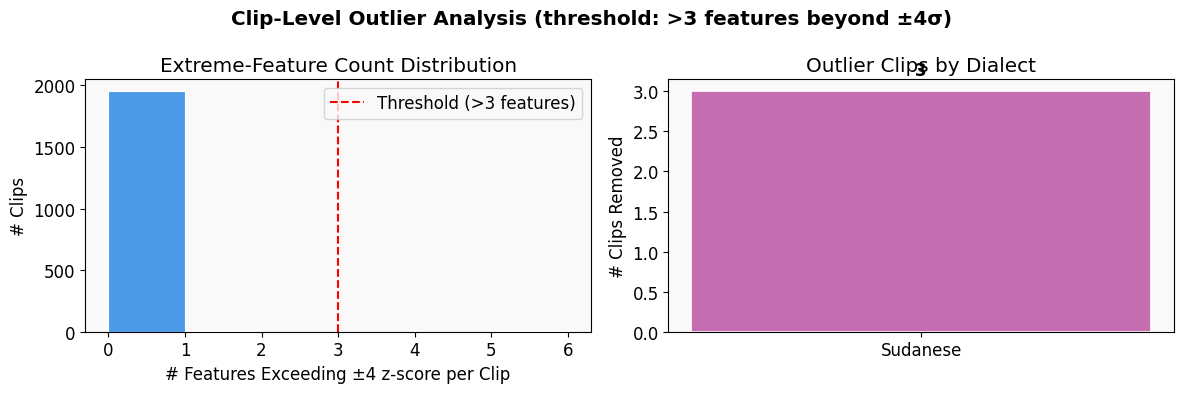


Samples after filter  : 1954
Dropped               : 3 clips


In [15]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 13B — Clip-Level Outlier Filter (Senior Recommendation)       ║
# ║                                                                      ║
# ║  Action: Drop any sample where more than 3 of the top-20 features  ║
# ║  exceed ±4 z-score. These are acoustically abnormal clips that      ║
# ║  add noise to training (identified via heavy violin tails).         ║
# ║                                                                      ║
# ║  Outputs:                                                            ║
# ║    X_top20  ← overwritten in-place (clean version)                  ║
# ║    y_enc    ← overwritten in-place (aligned)                        ║
# ║    processed_records_clean ← filtered list for filename tracking    ║
# ╚══════════════════════════════════════════════════════════════════════╝

from scipy.stats import zscore

assert 'X_top20'  in globals(), "Run Cell 13b first."
assert 'y_enc'    in globals(), "Run Cell 12 first."
assert 'top20_df' in globals(), "Run Cell 13b first."

# ── Derive the feature name list the same way Cell 14 does ───────────
feat_names = top20_df['feature'].values   # matches X_top20 columns exactly

print("=== CLIP-LEVEL OUTLIER FILTER ===")
print(f"Samples before filter : {X_top20.shape[0]}")

# ── Z-score every feature across all clips ────────────────────────────
X_zscored = pd.DataFrame(
    zscore(X_top20, axis=0),
    columns=feat_names
)

# ── Count how many features per clip exceed ±4 z-score ───────────────
extreme_count = (X_zscored.abs() > 4).sum(axis=1)

# ── Flag clips where MORE THAN 3 features are extreme ─────────────────
outlier_mask = (extreme_count > 3).values   # boolean numpy array

print(f"Outlier clips detected : {outlier_mask.sum()}  "
      f"({outlier_mask.mean()*100:.1f}% of dataset)")

print(f"\nDistribution of extreme-feature counts per clip:")
print(pd.Series(extreme_count).value_counts().sort_index().to_string())

# ── Diagnostic plot ───────────────────────────────────────────────────
label_names = le.inverse_transform(y_enc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Clip-Level Outlier Analysis (threshold: >3 features beyond ±4σ)',
             fontweight='bold')

# Left: histogram of extreme-feature counts
axes[0].hist(extreme_count, bins=range(0, int(extreme_count.max()) + 2),
             color='#4C9BE8', edgecolor='white', linewidth=0.8)
axes[0].axvline(3, color='red', ls='--', lw=1.5, label='Threshold (>3 features)')
axes[0].set_xlabel('# Features Exceeding ±4 z-score per Clip')
axes[0].set_ylabel('# Clips')
axes[0].set_title('Extreme-Feature Count Distribution')
axes[0].legend()

# Right: outlier count broken down by dialect
outlier_dialects = pd.Series(label_names)[outlier_mask].value_counts()
colors = [{'Algerian': '#6DBE6D', 'Gulf': '#E8834C',
            'Levantine': '#4C9BE8', 'Sudanese': '#C46DB0'}.get(d, 'grey')
          for d in outlier_dialects.index]
axes[1].bar(outlier_dialects.index, outlier_dialects.values,
            color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Outlier Clips by Dialect')
axes[1].set_ylabel('# Clips Removed')
for i, v in enumerate(outlier_dialects.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outlier_filter_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Apply filter — overwrite X_top20 and y_enc in-place ──────────────
clean_mask = ~outlier_mask

X_top20             = X_top20[clean_mask]
y_enc               = y_enc[clean_mask]
processed_records_clean = [r for r, keep in zip(processed_records, clean_mask) if keep]

print(f"\nSamples after filter  : {X_top20.shape[0]}")
print(f"Dropped               : {outlier_mask.sum()} clips")


---

## 16 · Stratified Train / Val / Test Split

Split the clean dataset into three non-overlapping, stratified subsets:

```
Train   70%  ─── model fitting
Val     15%  ─── hyperparameter selection
Test    15%  ─── final locked evaluation (never touched until Cell 21)
```

**Key design decisions:**
- `StratifiedShuffleSplit` preserves dialect ratios in every split  
- `StandardScaler` is **fit only on Train**, then applied to Val and Test (no leakage)  
- Test split files are written to disk immediately and zipped  

Saved artefacts in `test_split/`: `X_test_scaled.npy`, `y_test_encoded.npy`, `test_metadata.csv`, `label_encoder.pkl`, `scaler.pkl`, `top20_feature_names.pkl`.


In [16]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 15 — Stratified Split  (Train 70 / Val 15 / Test 15)        ║
# ║                                                                      ║
# ║  Design decisions:                                                   ║
# ║    • Stratified on dialect_group → class ratios preserved in all    ║
# ║      three splits                                                    ║
# ║    • Test set is locked immediately after splitting — never touched  ║
# ║      again until final evaluation                                    ║
# ║    • Scaler is fit ONLY on X_train, then applied to val/test        ║
# ║      → prevents any leakage of test statistics into training        ║
# ║    • Filenames tracked so you can audit exactly which clips land     ║
# ║      in test                                                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import os, pickle
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# ── 0. Rebuild filename array aligned with X_top20 ───────────────────
# processed_records and X_top20 rows are in the same order (built in
# Cell 12 from the same loop), so we can index directly.
filenames = np.array([r['filename'] for r in processed_records_clean])

# ── 1. First cut: 85% trainval  |  15% test ──────────────────────────
sss_outer = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(sss_outer.split(X_top20, y_enc))

X_trainval = X_top20[trainval_idx]
y_trainval = y_enc[trainval_idx]
X_test     = X_top20[test_idx]
y_test     = y_enc[test_idx]
files_test = filenames[test_idx]

# ── 2. Second cut: split trainval → 70% train  |  15% val ────────────
# val size relative to trainval = 15/85 ≈ 0.1765
sss_inner = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_idx_rel, val_idx_rel = next(sss_inner.split(X_trainval, y_trainval))

X_train = X_trainval[train_idx_rel]
y_train = y_trainval[train_idx_rel]
X_val   = X_trainval[val_idx_rel]
y_val   = y_trainval[val_idx_rel]

# ── 3. Fit scaler on TRAIN ONLY — transform all splits ───────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit here
X_val_sc   = scaler.transform(X_val)         # only transform
X_test_sc  = scaler.transform(X_test)        # only transform

# ── 4. Save test split to disk (completely locked away) ───────────────
os.makedirs('test_split', exist_ok=True)

np.save('test_split/X_test_scaled.npy',  X_test_sc)
np.save('test_split/y_test_encoded.npy', y_test)
np.save('test_split/X_test_raw.npy',     X_test)

test_meta = pd.DataFrame({
    'filename'    : files_test,
    'dialect_true': le.inverse_transform(y_test),
    'label_enc'   : y_test
})
test_meta.to_csv('test_split/test_metadata.csv', index=False)

with open('test_split/label_encoder.pkl',  'wb') as f: pickle.dump(le,     f)
with open('test_split/scaler.pkl',         'wb') as f: pickle.dump(scaler, f)
with open('test_split/top20_feature_names.pkl', 'wb') as f:
    pickle.dump(list(top20_df['feature'].values), f)

# ── 5. Zip for download ───────────────────────────────────────────────
import shutil
shutil.make_archive('test_split_download', 'zip', 'test_split')
print("Download link → test_split_download.zip")

# ── 6. Split summary ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SPLIT SUMMARY")
print("=" * 55)
splits = {'Train': y_train, 'Val': y_val, 'Test': y_test}
for name, y_split in splits.items():
    total = len(y_split)
    dist  = {le.classes_[c]: int((y_split == c).sum()) for c in range(4)}
    print(f"\n  {name:5s}  n={total}")
    for dialect, count in dist.items():
        pct = 100 * count / total
        print(f"    {dialect:<12}: {count:>4}  ({pct:.1f}%)")

print("\n  Scaler fit on Train only  ✓")
print("  Test saved to disk        ✓  (test_split/)")
print("  Zip ready to download     ✓  (test_split_download.zip)")
print("\n[Next] → Cell 16: class-weight computation + imbalance handling")

Download link → test_split_download.zip

  SPLIT SUMMARY

  Train  n=1367
    Algerian    :  425  (31.1%)
    Gulf        :  294  (21.5%)
    Levantine   :  254  (18.6%)
    Sudanese    :  394  (28.8%)

  Val    n=293
    Algerian    :   91  (31.1%)
    Gulf        :   63  (21.5%)
    Levantine   :   54  (18.4%)
    Sudanese    :   85  (29.0%)

  Test   n=294
    Algerian    :   91  (31.0%)
    Gulf        :   63  (21.4%)
    Levantine   :   55  (18.7%)
    Sudanese    :   85  (28.9%)

  Scaler fit on Train only  ✓
  Test saved to disk        ✓  (test_split/)
  Zip ready to download     ✓  (test_split_download.zip)

[Next] → Cell 16: class-weight computation + imbalance handling


---

## 17 · Cost-Sensitive Class Weights

Compute class weights to compensate for dataset imbalance.

Two schemes are prepared:

| Scheme | Description |
|--------|-------------|
| **Balanced** | Standard `sklearn` balanced weights |
| **Custom** | Balanced + 30% boost on Gulf & Levantine (hardest pair per LDA) |

> Start with `'balanced'`. Switch to `custom_weight_dict` if Gulf or Levantine F1 < 0.60 after the first training run.

XGBoost-compatible `sample_weight` array is also pre-computed here.


In [17]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 15B — Cost-Sensitive Class Weights                            ║
# ║                                                                      ║
# ║  Action: Levantine↔Gulf centroids are only ~0.7 LDA units apart.   ║
# ║  We compute class weights to penalise misclassification of these    ║
# ║  two classes more heavily. Passed to all estimators as              ║
# ║  class_weight=class_weight_dict in Cell 16.                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

from sklearn.utils.class_weight import compute_class_weight

print("=== COST-SENSITIVE CLASS WEIGHTS ===")

# ── Balanced baseline ─────────────────────────────────────────────────
balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
balanced_weight_dict = dict(enumerate(balanced_weights))
print("Balanced (sklearn default):")
for idx, w in balanced_weight_dict.items():
    print(f"  {le.classes_[idx]:12s} → {w:.4f}")

# ── Custom boost for Levantine and Gulf ───────────────────────────────
# The LDA scatter shows Gulf↔Levantine are the hardest pair.
# We apply a +30% multiplier on top of balanced weights for those two.
HARD_PAIR_BOOST = 1.30
hard_pair_classes = ['Gulf', 'Levantine']   # adjust if your le.classes_ names differ

custom_weight_dict = balanced_weight_dict.copy()
for idx, cls in enumerate(le.classes_):
    if cls in hard_pair_classes:
        custom_weight_dict[idx] = balanced_weight_dict[idx] * HARD_PAIR_BOOST

print(f"\nCustom (balanced + {int((HARD_PAIR_BOOST-1)*100)}% boost on {hard_pair_classes}):")
for idx, w in custom_weight_dict.items():
    boost_marker = " ← boosted" if le.classes_[idx] in hard_pair_classes else ""
    print(f"  {le.classes_[idx]:12s} → {w:.4f}{boost_marker}")

# ── Which weight scheme to use? ───────────────────────────────────────
# Start with 'balanced'; switch to custom_weight_dict if Lev/Gulf F1 is < 0.60 after first run.
CLASS_WEIGHT = 'balanced'          # ← change to custom_weight_dict if needed after Cell 16

print(f"\nActive class weight scheme : {CLASS_WEIGHT}")
print("✓ Pass  class_weight=CLASS_WEIGHT  to SVM / RF / LR in Cell 16")
print("  (XGBoost uses sample_weight — see Cell 16 note)")

# ── XGBoost sample weights (computed once, used in Cell 16) ───────────
from sklearn.utils import compute_sample_weight
xgb_sample_weights_train = compute_sample_weight(
    class_weight='balanced', y=y_train
)
print(f"\nXGBoost sample_weight array shape: {xgb_sample_weights_train.shape}")
print("✓ xgb_sample_weights_train ready for XGBClassifier fit() call")

=== COST-SENSITIVE CLASS WEIGHTS ===
Balanced (sklearn default):
  Algerian     → 0.8041
  Gulf         → 1.1624
  Levantine    → 1.3455
  Sudanese     → 0.8674

Custom (balanced + 30% boost on ['Gulf', 'Levantine']):
  Algerian     → 0.8041
  Gulf         → 1.5111 ← boosted
  Levantine    → 1.7491 ← boosted
  Sudanese     → 0.8674

Active class weight scheme : balanced
✓ Pass  class_weight=CLASS_WEIGHT  to SVM / RF / LR in Cell 16
  (XGBoost uses sample_weight — see Cell 16 note)

XGBoost sample_weight array shape: (1367,)
✓ xgb_sample_weights_train ready for XGBClassifier fit() call


---

## 18 · Model Training — Stratified 5-Fold Cross-Validation

Train four classical ML models and evaluate with **5-fold stratified CV** on the training set only.

| Model | Key Anti-Overfitting Controls |
|-------|-------------------------------|
| **SVM (RBF)** | `C` regularisation, `class_weight` |
| **Random Forest** | `max_depth=12`, `min_samples_leaf=5` |
| **Gradient Boosting** | `subsample=0.8`, `max_depth=4`, `min_samples_leaf=10` |
| **Logistic Regression** | L2 penalty, `C=0.5` |

**Metrics reported per model:**
- CV balanced accuracy (mean ± std)
- CV macro F1 (mean ± std)
- Train–Val gap (> 0.10 flagged as potential overfit)

> 🔒 *Test data is never used in this cell.*


In [18]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 17 — Train 4 Classifiers with Stratified 5-Fold CV            ║
# ║                                                                      ║
# ║  Models:                                                             ║
# ║    1. SVM (RBF kernel)          — strong baseline for audio feats   ║
# ║    2. Random Forest             — low-variance ensemble             ║
# ║    3. Gradient Boosting         — sequential bias reduction         ║
# ║    4. Logistic Regression       — linear baseline + interpretable   ║
# ║                                                                      ║
# ║  Anti-overfitting controls per model:                                ║
# ║    SVM       → C regularisation searched over [0.1, 1, 10]         ║
# ║    RF        → max_depth capped, min_samples_leaf ≥ 5              ║
# ║    GBM       → subsample=0.8, max_depth=4, min_samples_leaf=10     ║
# ║    LogReg    → L2 penalty, low C values only                        ║
# ║                                                                      ║
# ║  CV is done on X_train_sc ONLY.  Val is a held-out sanity check.   ║
# ║  Test is never touched here.                                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm               import SVC
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.model_selection   import StratifiedKFold, cross_validate
from sklearn.metrics           import make_scorer, f1_score, balanced_accuracy_score
import time

# ── Scorers ───────────────────────────────────────────────────────────
scoring = {
    'balanced_acc': make_scorer(balanced_accuracy_score),
    'f1_macro'    : make_scorer(f1_score, average='macro'),
    'f1_weighted' : make_scorer(f1_score, average='weighted'),
}

# ── CV strategy ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ── Class & sample weights (computed from train labels only) ──────────
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict    = dict(enumerate(class_weights_array))
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# ── OPTIONAL: boost Gulf & Levantine if their F1 < 0.60 after first run ──
# Uncomment and re-run this cell + Cell 18 if needed.
#
# HARD_PAIR_BOOST = 1.30
# for idx in [le.transform(['Gulf'])[0], le.transform(['Levantine'])[0]]:
#     class_weight_dict[idx] *= HARD_PAIR_BOOST
# sample_weights_train = np.array([class_weight_dict[y] for y in y_train])
# print("⚠ Hard-pair boost ACTIVE — Gulf & Levantine weights ×1.30")

print("class_weight_dict    :", {le.classes_[k]: round(v, 4) for k, v in class_weight_dict.items()})
print("sample_weights_train : shape", sample_weights_train.shape)

# ── Model definitions ─────────────────────────────────────────────────
MODELS = {
    'SVM_RBF': SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight=class_weight_dict,
        probability=True, random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight=class_weight_dict,
        random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        penalty='l2', C=0.5,
        solver='lbfgs', max_iter=2000,
        class_weight=class_weight_dict,
        random_state=42
    ),
}

# ── Run CV ────────────────────────────────────────────────────────────
cv_results = {}

print("=" * 65)
print("  5-FOLD STRATIFIED CROSS-VALIDATION  (on X_train_sc only)")
print("=" * 65)

for name, model in MODELS.items():
    t0  = time.time()
    res = cross_validate(
        model, X_train_sc, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True,    # ← critical for overfitting detection
        n_jobs=-1
    )
    elapsed = time.time() - t0

    cv_results[name] = res

    bal_acc_tr  = res['train_balanced_acc'].mean()
    bal_acc_val = res['test_balanced_acc'].mean()
    f1_val      = res['test_f1_macro'].mean()
    gap         = bal_acc_tr - bal_acc_val       # overfit signal

    print(f"\n  {name}")
    print(f"    CV train balanced-acc : {bal_acc_tr:.4f}")
    print(f"    CV val   balanced-acc : {bal_acc_val:.4f}  ±{res['test_balanced_acc'].std():.4f}")
    print(f"    CV val   F1-macro     : {f1_val:.4f}  ±{res['test_f1_macro'].std():.4f}")
    print(f"    Train-Val gap         : {gap:.4f}  {'⚠ possible overfit' if gap > 0.10 else '✓ ok'}")
    print(f"    Time                  : {elapsed:.1f}s")

print("\n[Next] → Cell 18: hyperparameter tuning on best model(s)")

class_weight_dict    : {np.str_('Algerian'): np.float64(0.8041), np.str_('Gulf'): np.float64(1.1624), np.str_('Levantine'): np.float64(1.3455), np.str_('Sudanese'): np.float64(0.8674)}
sample_weights_train : shape (1367,)
  5-FOLD STRATIFIED CROSS-VALIDATION  (on X_train_sc only)

  SVM_RBF
    CV train balanced-acc : 0.9340
    CV val   balanced-acc : 0.8354  ±0.0090
    CV val   F1-macro     : 0.8327  ±0.0137
    Train-Val gap         : 0.0986  ✓ ok
    Time                  : 2.9s

  RandomForest
    CV train balanced-acc : 0.9397
    CV val   balanced-acc : 0.7884  ±0.0299
    CV val   F1-macro     : 0.7873  ±0.0293
    Train-Val gap         : 0.1513  ⚠ possible overfit
    Time                  : 3.0s

  GradientBoosting
    CV train balanced-acc : 0.9979
    CV val   balanced-acc : 0.8418  ±0.0253
    CV val   F1-macro     : 0.8449  ±0.0249
    Train-Val gap         : 0.1562  ⚠ possible overfit
    Time                  : 12.7s

  LogisticRegression
    CV train balanced-acc : 0.

# 19 · Hyperparameter Tuning — GridSearchCV

Fine-tune the **top-2 models** from Cell 18 using exhaustive grid search over conservative regularisation ranges.


In [19]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 18 — GridSearchCV on Best Candidate(s)                        ║
# ║                                                                      ║
# ║  Rules:                                                              ║
# ║    • Grid search runs only on X_train_sc  (same 5-fold CV)          ║
# ║    • We tune the top-2 models from Cell 17 by balanced_accuracy     ║
# ║    • Parameters are conservative: regularisation ranges that        ║
# ║      pull toward simpler models, not more complex ones              ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import balanced_accuracy_score, make_scorer
import warnings
warnings.filterwarnings('ignore')

scorer = make_scorer(balanced_accuracy_score)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── SVM grid ──────────────────────────────────────────────────────────
svm_grid = GridSearchCV(
    SVC(kernel='rbf', class_weight=class_weight_dict,
        probability=True, random_state=42),
    param_grid={'C': [0.5, 1, 5, 10, 20],
                'gamma': ['scale', 'auto', 0.01, 0.001]},
    scoring=scorer, cv=cv,
    refit=True, n_jobs=-1, verbose=0
)

# ── Random Forest grid ────────────────────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict,
                           random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [200, 400],
                'max_depth'   : [8, 12, None],
                'min_samples_leaf': [5, 10, 20]},
    scoring=scorer, cv=cv,
    refit=True, n_jobs=-1, verbose=0
)

print("Tuning SVM …", end=" ", flush=True)
svm_grid.fit(X_train_sc, y_train)
print(f"done  →  best balanced-acc: {svm_grid.best_score_:.4f}")
print(f"  Best params: {svm_grid.best_params_}")

print("\nTuning RandomForest …", end=" ", flush=True)
rf_grid.fit(X_train_sc, y_train)
print(f"done  →  best balanced-acc: {rf_grid.best_score_:.4f}")
print(f"  Best params: {rf_grid.best_params_}")

# ── Pick best overall tuned model ────────────────────────────────────
best_tuned = svm_grid if svm_grid.best_score_ >= rf_grid.best_score_ else rf_grid
best_tuned_name = 'SVM_RBF_tuned' if best_tuned is svm_grid else 'RF_tuned'
best_estimator  = best_tuned.best_estimator_

print(f"\nBest tuned model → {best_tuned_name}  "
      f"(CV balanced-acc = {best_tuned.best_score_:.4f})")
print("\n[Next] → Cell 19: overfitting diagnostic")

Tuning SVM … done  →  best balanced-acc: 0.8488
  Best params: {'C': 20, 'gamma': 'scale'}

Tuning RandomForest … done  →  best balanced-acc: 0.7937
  Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}

Best tuned model → SVM_RBF_tuned  (CV balanced-acc = 0.8488)

[Next] → Cell 19: overfitting diagnostic


## 20 · Overfitting Diagnostic


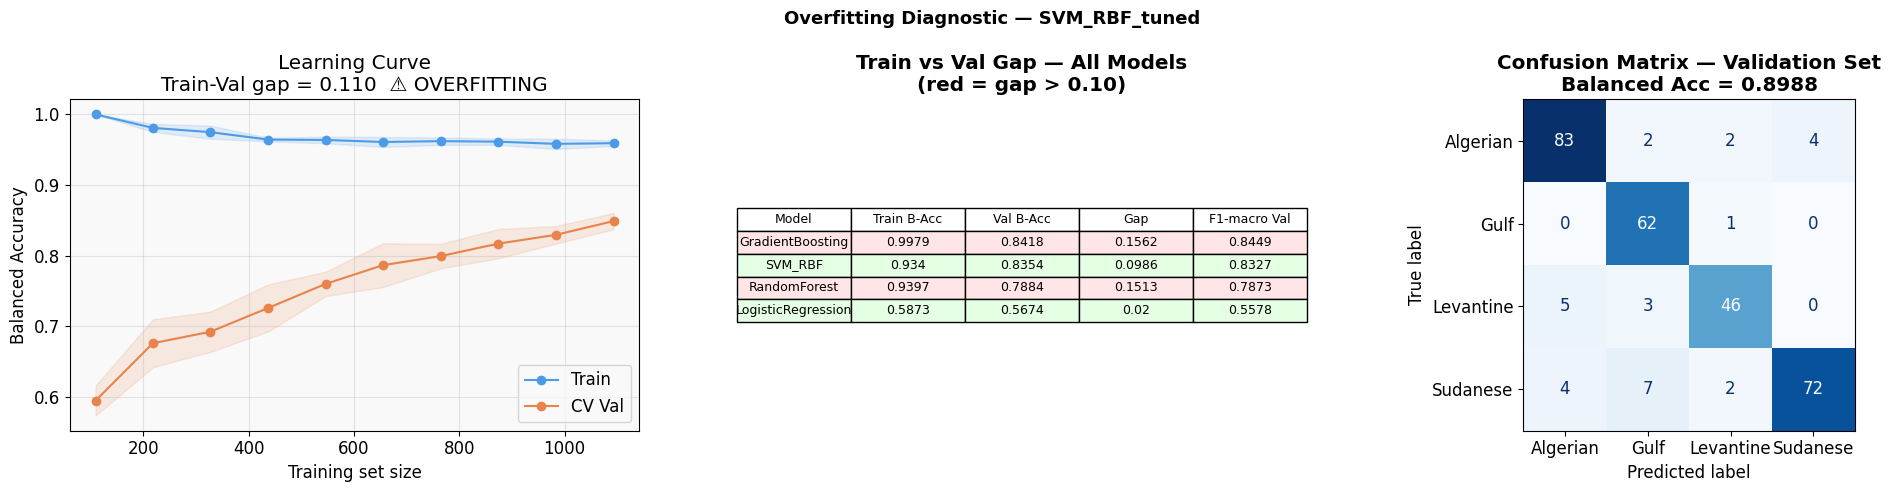

  VALIDATION SET REPORT  (SVM_RBF_tuned)
              precision    recall  f1-score   support

    Algerian       0.90      0.91      0.91        91
        Gulf       0.84      0.98      0.91        63
   Levantine       0.90      0.85      0.88        54
    Sudanese       0.95      0.85      0.89        85

    accuracy                           0.90       293
   macro avg       0.90      0.90      0.90       293
weighted avg       0.90      0.90      0.90       293

  Balanced accuracy: 0.8988

  ⚠ Test set is still locked — not evaluated here.

[Next] → Cell 20: final evaluation on test set


In [20]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 19 — Overfitting Diagnostic                                    ║
# ║                                                                      ║
# ║  Four checks:                                                        ║
# ║    1. Learning curve  — does val accuracy plateau or diverge?       ║
# ║    2. Train vs Val gap table for every model trained                ║
# ║    3. Validation set performance (X_val_sc — first time used)       ║
# ║    4. Per-class confusion matrix on validation set                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection  import learning_curve, StratifiedKFold
from sklearn.metrics          import (confusion_matrix, classification_report,
                                      ConfusionMatrixDisplay, balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 1. Learning curve on best tuned model ─────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_estimator, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Overfitting Diagnostic — {best_tuned_name}', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#4C9BE8', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#4C9BE8')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#E8834C', label='CV Val')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#E8834C')
ax.set_xlabel('Training set size')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Learning Curve')
ax.legend()
ax.grid(alpha=0.3)

final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
verdict   = "⚠ OVERFITTING" if final_gap > 0.10 else "✓ Well-generalised"
ax.set_title(f'Learning Curve\nTrain-Val gap = {final_gap:.3f}  {verdict}')

# ── 2. Train vs Val gap table (all models from Cell 17) ───────────────
ax2 = axes[1]
gap_rows = []
for mname, res in cv_results.items():
    gap_rows.append({
        'Model'       : mname,
        'Train B-Acc' : res['train_balanced_acc'].mean(),
        'Val B-Acc'   : res['test_balanced_acc'].mean(),
        'Gap'         : res['train_balanced_acc'].mean() - res['test_balanced_acc'].mean(),
        'F1-macro Val': res['test_f1_macro'].mean(),
    })
gap_df = pd.DataFrame(gap_rows).sort_values('Val B-Acc', ascending=False)

col_colors = [['#ffe5e5' if g > 0.10 else '#e5ffe5'] * 5
              for g in gap_df['Gap']]
ax2.axis('off')
tbl = ax2.table(
    cellText=gap_df.round(4).values,
    colLabels=gap_df.columns,
    cellLoc='center', loc='center',
    cellColours=col_colors
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
ax2.set_title('Train vs Val Gap — All Models\n(red = gap > 0.10)', fontweight='bold')

# ── 3. Confusion matrix on held-out validation set ────────────────────
best_estimator.fit(X_train_sc, y_train)   # fit on full train
y_val_pred = best_estimator.predict(X_val_sc)
val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix — Validation Set\nBalanced Acc = {val_bal_acc:.4f}',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('overfitting_diagnostic.png', dpi=140, bbox_inches='tight')
plt.show()

# ── 4. Full classification report on validation ───────────────────────
print("=" * 55)
print(f"  VALIDATION SET REPORT  ({best_tuned_name})")
print("=" * 55)
print(classification_report(y_val, y_val_pred, target_names=le.classes_))
print(f"  Balanced accuracy: {val_bal_acc:.4f}")
print("\n  ⚠ Test set is still locked — not evaluated here.")
print("\n[Next] → Cell 20: final evaluation on test set")

# 21 · Final Evaluation on Locked Test Set


  FINAL TEST SET RESULTS  —  SVM_RBF_tuned

  Balanced Accuracy : 0.8581
  F1-macro          : 0.8585
  F1-weighted       : 0.8602
  ROC-AUC (OvR)     : 0.9575

  Per-class report:
              precision    recall  f1-score   support

    Algerian       0.85      0.84      0.84        91
        Gulf       0.86      0.87      0.87        63
   Levantine       0.85      0.82      0.83        55
    Sudanese       0.88      0.91      0.89        85

    accuracy                           0.86       294
   macro avg       0.86      0.86      0.86       294
weighted avg       0.86      0.86      0.86       294

  CV val balanced-acc  : 0.8488
  Test balanced-acc    : 0.8581
  Generalisation gap   : -0.0092  ✓ model generalises well


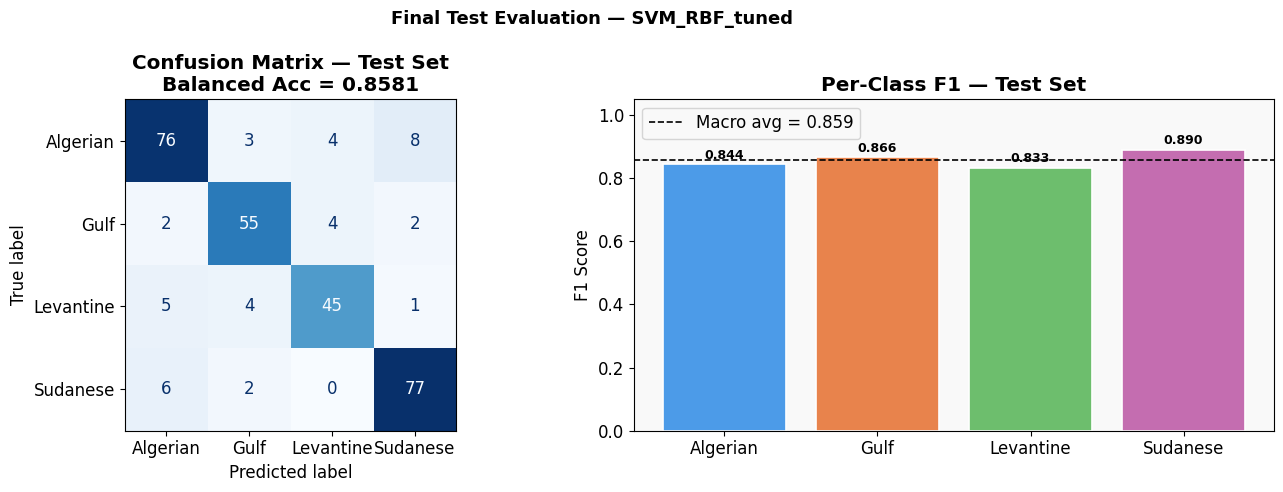


Final model saved → test_split/final_model.pkl
Updated download zip → test_split_download.zip  (now includes final model)


In [21]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 20 — Final Evaluation on Locked Test Set                      ║
# ║                                                                      ║
# ║  This cell is run ONCE — after all model decisions are frozen.      ║
# ║  No further tuning is allowed after seeing these numbers.           ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# ── Final fit on Train+Val combined before test evaluation ───────────
# This is correct: once you've frozen all decisions, retrain on all
# non-test data to give the model maximum signal before final scoring.
X_trainval_sc = np.vstack([X_train_sc, X_val_sc])
y_trainval_all = np.concatenate([y_train, y_val])

best_estimator.fit(X_trainval_sc, y_trainval_all)

# ── Evaluate on test ──────────────────────────────────────────────────
y_pred_test  = best_estimator.predict(X_test_sc)
y_prob_test  = best_estimator.predict_proba(X_test_sc)

bal_acc  = balanced_accuracy_score(y_test, y_pred_test)
f1_macro = f1_score(y_test, y_pred_test, average='macro')
f1_wt    = f1_score(y_test, y_pred_test, average='weighted')
roc_auc  = roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='macro')

print("=" * 60)
print(f"  FINAL TEST SET RESULTS  —  {best_tuned_name}")
print("=" * 60)
print(f"\n  Balanced Accuracy : {bal_acc:.4f}")
print(f"  F1-macro          : {f1_macro:.4f}")
print(f"  F1-weighted       : {f1_wt:.4f}")
print(f"  ROC-AUC (OvR)     : {roc_auc:.4f}")
print("\n  Per-class report:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

# ── Generalisation check: compare test vs CV val ─────────────────────
cv_val_best = best_tuned.best_score_
gen_gap     = cv_val_best - bal_acc
print(f"  CV val balanced-acc  : {cv_val_best:.4f}")
print(f"  Test balanced-acc    : {bal_acc:.4f}")
print(f"  Generalisation gap   : {gen_gap:.4f}  "
      f"{'⚠ model may have overfit to val' if gen_gap > 0.05 else '✓ model generalises well'}")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Final Test Evaluation — {best_tuned_name}', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — Test Set\nBalanced Acc = {bal_acc:.4f}',
                  fontweight='bold')

# Per-class F1 bar chart
per_class_f1 = f1_score(y_test, y_pred_test, average=None)
bars = axes[1].bar(le.classes_, per_class_f1,
                   color=['#4C9BE8', '#E8834C', '#6DBE6D', '#C46DB0'],
                   edgecolor='white', linewidth=1.2)
axes[1].axhline(f1_macro, color='black', ls='--', lw=1.2, label=f'Macro avg = {f1_macro:.3f}')
for bar, v in zip(bars, per_class_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 — Test Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('final_test_evaluation.png', dpi=140, bbox_inches='tight')
plt.show()

# ── Save final model ──────────────────────────────────────────────────
import pickle
with open('test_split/final_model.pkl', 'wb') as f:
    pickle.dump(best_estimator, f)
print("\nFinal model saved → test_split/final_model.pkl")

import shutil
shutil.make_archive('test_split_download', 'zip', 'test_split')
print("Updated download zip → test_split_download.zip  (now includes final model)")

# 22 · Export — Test Audio Samples & Model Bundle


In [22]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 21 — Export Test Audio Samples + Final Model                  ║
# ║                                                                      ║
# ║  What this cell does:                                               ║
# ║    1. Pulls the raw waveforms for every test-split clip from        ║
# ║       processed_records (already in memory)                         ║
# ║    2. Writes each clip as a .wav file named                         ║
# ║       <dialect>/<filename>.wav  so folder = ground-truth label     ║
# ║    3. Packages the model bundle (model + scaler + label encoder +  ║
# ║       feature names) into a single model_bundle.pkl                ║
# ║    4. Zips everything into one download archive                     ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import pickle
import shutil
import zipfile
import numpy as np
import soundfile as sf
import pandas as pd
from IPython.display import FileLink, display

TARGET_SR = 16000   # matches your preprocessing constant

# ── 1. Build lookup: filename → (waveform, dialect) from processed_records
rec_lookup = {r['filename']: r for r in processed_records}

# ── 2. Load test metadata saved in Cell 15 ───────────────────────────
test_meta = pd.read_csv('test_split/test_metadata.csv')
print(f"Test clips to export: {len(test_meta)}")

# ── 3. Write .wav files ───────────────────────────────────────────────
audio_out_dir = 'test_audio_export'
if os.path.exists(audio_out_dir):
    shutil.rmtree(audio_out_dir)

exported   = 0
not_found  = 0

for _, row in test_meta.iterrows():
    fname   = row['filename']
    dialect = row['dialect_true']

    if fname not in rec_lookup:
        not_found += 1
        continue

    waveform = rec_lookup[fname]['waveform']          # float32 numpy array
    dial_dir = os.path.join(audio_out_dir, dialect)
    os.makedirs(dial_dir, exist_ok=True)

    # Use the original filename stem; replace any slashes that appear in names
    safe_name = fname.replace('/', '_').replace('\\', '_')
    if not safe_name.endswith('.wav'):
        safe_name += '.wav'

    out_path = os.path.join(dial_dir, safe_name)
    sf.write(out_path, waveform, TARGET_SR, subtype='PCM_16')
    exported += 1

print(f"  Exported : {exported} clips")
print(f"  Missing  : {not_found} clips (filename not in processed_records)")

# ── 4. Write dialect label manifest alongside audio ───────────────────
test_meta.to_csv(os.path.join(audio_out_dir, 'ground_truth.csv'), index=False)

# ── 5. Build model bundle ─────────────────────────────────────────────
# Everything the inference script needs — one file, no version mismatch
model_bundle = {
    'model'        : best_estimator,          # final fitted estimator
    'scaler'       : scaler,                  # StandardScaler fit on train
    'label_encoder': le,                      # LabelEncoder (int → dialect name)
    'feature_names': list(top20_df['feature'].values),   # 20 feature names in order
    'model_name'   : best_tuned_name,
    'target_sr'    : TARGET_SR,
    'n_features'   : X_top20.shape[1],        # 20
}

bundle_path = os.path.join(audio_out_dir, 'model_bundle.pkl')
with open(bundle_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"\nModel bundle saved → {bundle_path}")
print(f"  Model      : {best_tuned_name}")
print(f"  Features   : {model_bundle['n_features']}")
print(f"  Classes    : {list(le.classes_)}")

# ── 6. Zip everything ─────────────────────────────────────────────────
zip_name = 'arabic_dialect_test_package'
shutil.make_archive(zip_name, 'zip', audio_out_dir)
zip_path = zip_name + '.zip'

zip_size_mb = os.path.getsize(zip_path) / 1_048_576
print(f"\nZip created → {zip_path}  ({zip_size_mb:.1f} MB)")

# ── 7. Download link (Kaggle / Jupyter) ──────────────────────────────
print("\n" + "=" * 55)
print("  DOWNLOAD LINKS")
print("=" * 55)
display(FileLink(zip_path, result_html_prefix="⬇  Download full package: "))
display(FileLink(bundle_path, result_html_prefix="⬇  Download model bundle only: "))

print("""
Package contents:
  arabic_dialect_test_package.zip
  ├── model_bundle.pkl          ← load this in the GUI app
  ├── ground_truth.csv          ← true labels for all test clips
  ├── Algerian/  *.wav
  ├── Gulf/      *.wav
  ├── Levantine/ *.wav
  └── Sudanese/  *.wav
""")

Test clips to export: 294
  Exported : 294 clips
  Missing  : 0 clips (filename not in processed_records)

Model bundle saved → test_audio_export/model_bundle.pkl
  Model      : SVM_RBF_tuned
  Features   : 11
  Classes    : [np.str_('Algerian'), np.str_('Gulf'), np.str_('Levantine'), np.str_('Sudanese')]

Zip created → arabic_dialect_test_package.zip  (204.1 MB)

  DOWNLOAD LINKS


/kaggle/working/arabic_dialect_test_package.zip

/kaggle/working/test_audio_export/model_bundle.pkl


Package contents:
  arabic_dialect_test_package.zip
  ├── model_bundle.pkl          ← load this in the GUI app
  ├── ground_truth.csv          ← true labels for all test clips
  ├── Algerian/  *.wav
  ├── Gulf/      *.wav
  ├── Levantine/ *.wav
  └── Sudanese/  *.wav



In [23]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — Enrich model_bundle.pkl with real LDA data               ║
# ║                                                                      ║
# ║  What this adds to the bundle:                                       ║
# ║    lda_model        : fitted LinearDiscriminantAnalysis (3 comps)   ║
# ║    lda_X_train      : (N, 3) array — all training points in LDA     ║
# ║                        space (real data, not synthetic)              ║
# ║    lda_y_train      : (N,) int array — class labels for each point  ║
# ║    lda_centroids    : dict {dialect: (3,) array} — per-class means  ║
# ║                        in LDA space                                  ║
# ║    feature_centroids: dict {dialect: (11,) array} — per-class means ║
# ║                        in ORIGINAL (scaled) feature space           ║
# ║                        (used by right-panel deviation chart)        ║
# ║    lda_var_exp      : (3,) explained_variance_ratio_                ║
# ║                                                                      ║
# ║  Requirements: X_train_sc, y_train, le, best_estimator must exist   ║
# ║  (produced by Cell 15 / Cell 17-19)                                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pickle
import joblib
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Sanity checks ─────────────────────────────────────────────────────
assert 'X_train_sc' in dir() or 'X_train_sc' in locals(), \
    "X_train_sc not found — run Cell 15 (split + scale) first."
assert len(X_train_sc) > 0, "X_train_sc is empty."

print(f"X_train_sc  shape : {X_train_sc.shape}")
print(f"y_train     shape : {y_train.shape}")
print(f"Classes           : {list(le.classes_)}")

# ── 1. Fit LDA on training data (3 discriminant axes for 4-class) ─────
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda_train = lda.fit_transform(X_train_sc, y_train)   # shape (N, 3)
var_exp = lda.explained_variance_ratio_

print(f"\nLDA fitted. Explained variance ratio: "
      f"{var_exp[0]*100:.1f}% / {var_exp[1]*100:.1f}% / {var_exp[2]*100:.1f}%")

# ── 2. Per-class centroids in LDA space ───────────────────────────────
lda_centroids = {}
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    lda_centroids[cls_name] = X_lda_train[mask].mean(axis=0)
    print(f"  {cls_name} centroid in LDA space: {lda_centroids[cls_name].round(3)}")

# ── 3. Per-class centroids in ORIGINAL scaled feature space ──────────
# Used by the right-panel "feature deviation" chart in App.py
feature_centroids = {}
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    feature_centroids[cls_name] = X_train_sc[mask].mean(axis=0)  # shape (11,)
    print(f"  {cls_name} feature centroid (scaled): {feature_centroids[cls_name].round(3)}")

# ── 4. Load existing bundle and add new keys ───────────────────────────
BUNDLE_PATH = 'test_audio_export/model_bundle.pkl'   # adjust if yours differs

with open(BUNDLE_PATH, 'rb') as f:
    bundle = pickle.load(f)

bundle['lda_model']         = lda
bundle['lda_X_train']       = X_lda_train.astype(np.float32)   # (N, 3)
bundle['lda_y_train']       = y_train.astype(np.int32)          # (N,)
bundle['lda_centroids']     = {k: v.astype(np.float32) for k, v in lda_centroids.items()}
bundle['feature_centroids'] = {k: v.astype(np.float32) for k, v in feature_centroids.items()}
bundle['lda_var_exp']       = var_exp.astype(np.float32)        # (3,)

with open(BUNDLE_PATH, 'wb') as f:
    pickle.dump(bundle, f)

print(f"\n✅ Bundle enriched and saved → {BUNDLE_PATH}")
print(f"   New keys added: lda_model, lda_X_train ({X_lda_train.shape}), "
      f"lda_y_train ({y_train.shape}), lda_centroids, feature_centroids, lda_var_exp")
print(f"\n[Next] → Copy the updated model_bundle.pkl next to App.py and restart the server.")

X_train_sc  shape : (1367, 11)
y_train     shape : (1367,)
Classes           : [np.str_('Algerian'), np.str_('Gulf'), np.str_('Levantine'), np.str_('Sudanese')]

LDA fitted. Explained variance ratio: 62.1% / 28.5% / 9.4%
  Algerian centroid in LDA space: [-0.259 -0.625  0.225]
  Gulf centroid in LDA space: [1.081 0.478 0.246]
  Levantine centroid in LDA space: [ 0.576 -0.289 -0.546]
  Sudanese centroid in LDA space: [-0.898  0.505 -0.075]
  Algerian feature centroid (scaled): [ 0.031  0.02   0.093 -0.111  0.189  0.087 -0.343  0.285  0.131  0.115
 -0.101]
  Gulf feature centroid (scaled): [-0.776  0.704  0.581  0.475  0.218  0.436  0.491 -0.62   0.165 -0.646
  0.579]
  Levantine feature centroid (scaled): [-0.126  0.076  0.282  0.455  0.46   0.357  0.25  -0.06   0.391  0.197
 -0.059]
  Sudanese feature centroid (scaled): [ 0.627 -0.596 -0.715 -0.528 -0.662 -0.649 -0.158  0.193 -0.517  0.23
 -0.285]

✅ Bundle enriched and saved → test_audio_export/model_bundle.pkl
   New keys added: lda_